<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Комментарий ревьюера</b>

Привет, Михаил! Давай знакомиться! Меня зовут Дмитрий Махортов, и я буду проверять твой проект. Сразу предлагаю общение на «ты» 🙂, но если тебе это не комфортно, то дай знать, и мы перейдем на «вы».

Моя основная цель - не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе погрузиться в увлекательный мир работы с данными и вырасти в крепкого профи. Это отдаленная цель. А ближайшая - сделать твою работу еще лучше )).

Все ключевые этапы в работе выполнены, и я вижу что с проектом ты справляешься. Есть моменты, которые нужно доработать, но я уверен, у тебя все получится.

Расскажу как обычно проходит проверка:
Бывают моменты, которые требуют пристального внимания. Комментарии по ним выделены <span style='background-color:#F7B3A4'> красным цветом </span> и обозначены значком 🛑. После их доработки проект будет принят.  🙂

<span style='background-color:#B7EBA7'> Зеленым цветом </span> и значком ✅ отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах. Или советы «со звездочкой», которые помогут тебе в будущем.

<span style='background-color:#F9EDA6'>Жёлтым цветом </span> и значком ⚠️ выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно).

Давай работать над проектом в диалоге: **если ты что-то меняешь в проекте по моим рекомендациям - пиши об этом**. Выбери для своих комментариев какой-то заметный цвет, так мне будет легче отследить изменения. Пожалуйста, **не перемещай, не изменяй и не удаляй мои комментарии**. Всё это поможет выполнить повторную проверку твоего проекта оперативнее. </div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>образец комментария студента</b></font>

Можешь использовать этот комментарий. Просто удали этот текст и вместо него напиши свой 🙂

</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

Привет, Дмитрий! Спасибо за тёплый приём и подробный разбор первой версии проекта 🙂 На «ты» — с удовольствием.

С системой пометок всё понятно. Свои комментарии оформляю фиолетовым цветом, чтобы было легче отследить изменения; твои комментарии не перемещал и не удалял.
</div>

# 🚚⚠️📊 Прогнозирование риска задержки доставки CargaPronto: сегментация клиентов и бинарная классификация заказов

Автор: Якунин Михаил

Дата: "05" октября 2026 г.

***По этой ссылке можно посмотреть проект и скачать последнюю версию: https://github.com/MEYakunin/Sprint18_Delivery_Delay_Prediction.git***

## Цель проекта

*Цель проекта* — построить для логистической компании CargaPronto модель бинарной классификации, которая по данным о заказе и профиле клиента будет предсказывать риск задержки доставки (`late_delivery_risk`) ещё в момент оформления заказа. 

*Конечный продукт* — система поддержки принятия решений для диспетчеров: при высоком риске опоздания (>70%) система должна выдавать предупреждение и рекомендовать сменить приоритет доставки, что позволит компании активно управлять ситуацией вместо того, чтобы констатировать факт нарушения SLA.

*Ключевая задача исследования* — проверить гипотезу транспортного департамента о «неоднородности» клиентской базы: подтвердить, что риск задержки определяется не только параметрами самого заказа, но и географическим положением клиента, а также его поведенческим профилем (частота заказов, сумма покупок, доля возвратов, чувствительность к скидкам). Для этого клиенты будут сегментированы с помощью кластеризации K-Means++ на логистические зоны (`geo_cluster`) и поведенческие сегменты (`beh_cluster`), после чего полученные признаки добавляются в обучающие данные моделей.

*Целевой показатель качества* — ROC-AUC > 0.75 на тестовой выборке: метрика оценивает способность модели ранжировать заказы по степени риска, что позволит диспетчерам точечно выделять доставки, требующие повышенного внимания.

## Задача проекта

*Задача проекта* — разработать модель бинарной классификации, которая в момент оформления заказа предсказывает целевую переменную `late_delivery_risk`: 1 — заказ доставлен с задержкой, 0 — доставлен вовремя. Входными данными служат параметры самого заказа (`order_id`, `customer_id`, `order_date`, `shipping_mode`, `category_name`, `item_price`) и профиль клиента из справочника (`customer_lat`, `customer_lon`, `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`).

*Инструменты моделирования* — логистическая регрессия (быстрая и прозрачная, задаёт «нижнюю планку» качества) и `CatBoostClassifier` (градиентный бустинг, способный находить сложные закономерности). Метрика качества — `ROC-AUC`: она оценивает способность модели ранжировать заказы по степени риска, что позволяет диспетчерам точечно выделять доставки, требующие повышенного внимания. Удовлетворительный результат — `ROC-AUC` > 0.75 на тестовой выборке.

*План работы:*
1. Загрузка датасетов `ds_s18_customers.csv` и `ds_s18_orders.csv`, технический аудит, устранение полных дубликатов, проверка целостности данных, подготовка временных признаков `order_month`, `order_weekday`, `order_hour`.
2. EDA: проверка баланса классов, географический аудит и удаление аномалий координат, анализ зависимостей признаков.
3. Разделение заказов на обучающую, валидационную и тестовую выборки в соотношении 60:20:20 с помощью `GroupShuffleSplit` (клиенты не должны пересекаться между выборками).
4. Обучение базовых моделей (логистическая регрессия и `CatBoostClassifier`) на признаках заказа — фиксация точки отсчёта качества.
5. Кластеризация клиентов: геокластеры (`geo_cluster`) по координатам и поведенческие сегменты (`beh_cluster`) по RFM-признакам, с выбором числа кластеров методом локтя и защитой от утечки данных.
6. Обучение финальных моделей на расширенном наборе признаков и оценка ROC-AUC на валидационной выборке.
7. Тестирование лучшей модели на тестовой выборке: итоговый ROC-AUC, матрица ошибок, анализ важности признаков.
8. Выводы и бизнес-рекомендации для CargaPronto.

## Описание данных

В проекте используются два датасета, выгруженные из ERP-системы компании CargaPronto.

1. `ds_s18_customers.csv` — профили уникальных клиентов

Справочник содержит агрегированную информацию о каждом клиенте: географическое положение и поведенческие показатели, собранные по методу RFM.

| Признак | Описание |
| :--- | :--- |
| `customer_id` | Уникальный номер клиента в системе ERP; ключ для связи с таблицей заказов |
| `customer_lat` | Широта местонахождения клиента |
| `customer_lon` | Долгота местонахождения клиента |
| `recency` | Количество дней, прошедших с момента последнего заказа до точки отсчёта (Recency) |
| `total_orders` | Общее количество совершённых заказов (Frequency) |
| `total_sales` | Суммарная выручка, которую клиент принёс компании за всё время (Monetary) |
| `avg_discount` | Средний размер скидки, которую получает клиент; маркер чувствительности к акциям |
| `return_rate` | Доля проблемных заказов (возвраты и отмены); ключевой показатель нагрузки на курьеров |

2. `ds_s18_orders.csv` — заказы клиентов

Таблица событий, где зафиксирован каждый факт продажи и итог доставки; здесь находится целевая переменная.

| Признак | Описание |
| :--- | :--- |
| `order_id` | Уникальный номер заказа |
| `customer_id` | Идентификатор клиента; ключ для связи с профилем из справочника |
| `order_date` | Дата и время совершения покупки |
| `category_name` | Категория заказанного товара |
| `item_price` | Стоимость товара в заказе |
| `shipping_mode` | Режим доставки: Standard Class, First Class, Second Class, Same Day |
| `late_delivery_risk` | Целевая переменная: 1 — заказ доставлен с задержкой; 0 — заказ доставлен вовремя |

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Отличный старт! 👍**

Есть цель, постановка ML-задачи с метрикой и порогом 0.75, план работы и описание обеих таблиц. Читатель сразу понимает, что проверяется гипотеза о неоднородности клиентов и что кластеры пойдут в модель как новые признаки.
</div>

## Содержание <a id="content"></a>

* [1. Импорт библиотек, выполнение базовых настроек](#1)
* [2. Загрузка данных, первичное знакомство](#2)
  * [2.1. Технический аудит данных](#2_1)
  * [2.2. Устранение дубликатов и проверка целостности (ID-Check)](#2_2)
  * [2.3. Подготовка признаков даты и времени](#2_3)
  * [2.4. Промежуточный итог](#2_4)
* [3. EDA](#3)
  * [3.1. Проверка баланса классов](#3_1)
  * [3.2. Географический аудит](#3_2)
  * [3.3. Удаление аномалий](#3_3)
  * [3.4. Анализ зависимостей между признаками](#3_4)
* [4. Разделение на выборки](#4)
* [5. Обучение базовой модели](#5)
  * [5.1. Логистическая регрессия](#5_1)
  * [5.2. CatBoostClassifier](#5_2)
  * [5.3. Оценка качества на валидационной выборке](#5_3)
* [6. Кластеризация по признакам, связанным с местоположением](#6)
  * [6.1. Подготовка признаков и защита от утечки данных](#6_1)
  * [6.2. Выбор числа кластеров методом локтя](#6_2)
  * [6.3. Визуализация кластеров и центроидов](#6_3)
* [7. Кластеризация по признакам профилей клиентов](#7)
  * [7.1. Подготовка векторов признаков и предобработка](#7_1)
  * [7.2. Выбор числа кластеров методом локтя](#7_2)
  * [7.3. Анализ полученных сегментов](#7_3)
  * [7.4. Визуализация кластеров с помощью t-SNE](#7_4)
* [8. Обучение модели на новых признаках](#8)
  * [8.1. Добавление `geo_cluster` и `beh_cluster` в данные](#8_1)
  * [8.2. Обучение финальных моделей](#8_2)
  * [8.3. Оценка ROC-AUC на валидационной выборке](#8_3)
* [9. Дополнительное задание — подбор лучшего количества кластеров](#9)
* [10. Тестирование лучшей модели](#10)
  * [10.1. Предсказание на тестовой выборке и итоговый ROC-AUC](#10_1)
  * [10.2. Матрица ошибок](#10_2)
  * [10.3. Анализ важности признаков](#10_3)
* [11. Выводы и рекомендации](#11)

## [1. Импорт библиотек, выполнение базовых настроек](#content)<a id="1"></a>

Загрузите все необходимые для выполнения проекта библиотеки и другие компоненты.



In [1]:
#%pip install -r requirements.txt

In [2]:
# Стандартные библиотеки

# Сторонние библиотеки
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import phik

from catboost import CatBoostClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

d:\ProjectPython\Sprint18_Delivery_Delay_Prediction\.ml_env_sprint18\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Правильная организация импортов 👍**

Все библиотеки собраны в одной ячейке в начале ноутбука, а константы (`RANDOM_STATE`, границы долготы) вынесены отдельно. Так сразу видно, какие зависимости нужны проекту, и при перезапуске ядра достаточно прогнать верхние ячейки.
</div>

In [3]:
# Установка константных параметров
RANDOM_STATE = 42

# Рабочие границы: долгота -125…-20; широта > 0 (северное полушарие)
LON_MIN, LON_MAX = -125, -20
LAT_MIN = 0

In [4]:
# Настройки Pandas для отображения DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}'.replace(',', ' '))
pd.set_option('display.memory_usage', True)

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Отключает научную нотацию (экспоненциальную запись) на оси Y для всех графиков
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = [-99, 99]

# Подавляем INFO-сообщения Optuna, оставляем только предупреждения и ошибки 
optuna.logging.set_verbosity(optuna.logging.WARNING)

## [2. Загрузка данных, первичное знакомство](#content)<a id="2"></a>

* Загрузите датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv`.
  * Путь к первому файлу — `'/datasets/ds_s18_customers.csv'`.
  * Путь ко второму файлу — `'/datasets/ds_s18_orders.csv'`.
* Проведите технический аудит данных.
* Выявите и устраните полные дубликаты строк.
* Выполните проверку целостности данных (ID-Check).
* Подготовьте признаки, связанные с датой и временем.
* Создайте дополнительные колонки `order_month`, `order_weekday`, `order_hour`.

### [2.1. Технический аудит данных](#content)<a id="2_1"></a>

In [5]:
# Загружаем датасеты
df_customers = pd.read_csv('datasets/ds_s18_customers.csv')
df_orders = pd.read_csv('datasets/ds_s18_orders.csv')

# Создание словаря c датафреймами
dataframes = {
    'customers': df_customers,
    'orders': df_orders
}

In [6]:
# Создаем функцию для отображения данных
def primary_info(df, name):
    """
    Выводит базовую сводную информацию о DataFrame: заголовок с именем таблицы,
    первые 5 строк, сводку типов и пропусков, а также описательную статистику.
    """
    print('='*50)
    print(f'Информация о таблице: {name}')
    print('='*50)
    display(df.head(5))
    df.info()
    display(df.describe(include='all').T)
    print()

In [7]:
# Выводим первичную информацию 
for name, df in dataframes.items():
    primary_info(df, name)

Информация о таблице: customers


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.954,-97.508,472.450,1,0.060,0.000,793
1,2,38.376,-104.726,1 618.660,4,0.126,0.000,137
2,3,18.025,-66.615,3 189.200,5,0.105,0.000,230
3,4,33.670,-112.247,1 480.710,4,0.135,0.000,381
4,5,18.359,-66.078,1 101.920,3,0.140,0.000,458


<class 'pandas.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB


,count,mean,std,min,25%,50%,75%,max
customer_id,20 652.000,10 400.286,5 993.106,1.000,5 208.750,10 407.500,15 594.250,20 757.000
customer_lat,20 652.000,29.749,9.824,-33.938,18.266,33.216,39.292,48.782
customer_lon,20 652.000,-84.950,21.254,-158.026,-98.469,-76.760,-66.371,115.263
total_sales,20 652.000,1 600.542,1 508.418,8.470,254.940,1 294.505,2 621.140,9 436.610
total_orders,20 652.000,3.184,2.431,1.000,1.000,3.000,5.000,15.000
avg_discount,20 652.000,0.102,0.048,0.000,0.076,0.100,0.123,0.250
return_rate,20 652.000,0.043,0.157,0.000,0.000,0.000,0.000,1.000
recency,20 652.000,221.089,199.395,1.000,76.000,160.000,308.000,1 126.000



Информация о таблице: orders


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.750
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.750
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.750
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.750
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.750


<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  str    
 4   category_name       180519 non-null  str    
 5   order_date          180519 non-null  str    
 6   item_price          180519 non-null  float64
dtypes: float64(1), int64(3), str(3)
memory usage: 9.6 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,180 519.000,NaN,NaN,NaN,90 260.000,52 111.491,1.000,45 130.500,90 260.000,135 389.500,180 519.000
customer_id,180 519.000,NaN,NaN,NaN,6 691.379,4 162.918,1.000,3 258.500,6 457.000,9 779.000,20 757.000
late_delivery_risk,180 519.000,NaN,NaN,NaN,0.548,0.498,0.000,0.000,1.000,1.000,1.000
shipping_mode,180519,4,Standard Class,107752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,180519,65752,2016-10-25 14:39:00,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_price,180 519.000,NaN,NaN,NaN,141.233,139.732,9.990,50.000,59.990,199.990,1 999.990


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Первичный осмотр данных 👍**

Функция `primary_info` выводит `head`, `info` и `describe` для обеих таблиц одним вызовом: без дублирования кода и с аккуратными заголовками. В выводе под ячейкой сразу замечены строковый тип `order_date` и аномальная долгота - хорошая наблюдательность.
</div>

#### Промежуточный итог

1. Обе таблицы загружены без ошибок: `df_customers` — 20 652 строки × 8 колонок, `df_orders` — 180 519 строк × 7 колонок. Полных пропусков нет, что упрощает дальнейшую предобработку.

2. Типы данных в целом корректны, однако колонка `order_date` в `df_orders` хранится как строка (`str`) — на этапе подготовки признаков её необходимо преобразовать в тип `datetime`.

3. Категориальные признаки информативны: 4 режима доставки (доминирует Standard Class) и 50 категорий товаров (лидер — Cleats).

4. В географических координатах `customer_lon` обнаружены аномалии (пределы диапазона долготы –125 до –20): минимальное -158.026° и максимальное 115.263° — точки вне региона работы компании (США и Пуэрто-Рико). Эти выбросы будут удалены на этапе EDA, так как K-Means чувствителен к ним.

5. Память таблиц невелика (1.3 MB и 9.6 MB), оптимизация dtype не требуется.

*Вывод:* данные пригодны для дальнейшей работы. Следующие шаги — проверка полных дубликатов, контроль целостности связей (ID-Check) и подготовка временных признаков `order_month`, `order_weekday`, `order_hour`.

### [2.2. Устранение дубликатов и проверка целостности (ID-Check)](#content)<a id="2_2"></a>

In [8]:
# Проверяем полные дубликаты
print(f'Полных дубликатов в customers: {df_customers.duplicated().sum()}')
print(f'Полных дубликатов в orders:    {df_orders.duplicated().sum()}')

Полных дубликатов в customers: 0
Полных дубликатов в orders:    0


In [9]:
# Проверяем строки с повторяющимся customer_id и order_id
cust_dup = df_customers[df_customers.duplicated(subset=['customer_id'], keep=False)]
ord_dup = df_orders[df_orders.duplicated(subset=['order_id'], keep=False)]

print(f'Строк с повторяющимся customer_id в df_customers: {len(cust_dup)}')
print(f'Строк с повторяющимся order_id в df_orders: {len(ord_dup)}')

Строк с повторяющимся customer_id в df_customers: 0
Строк с повторяющимся order_id в df_orders: 0


In [10]:
# Проверяем строки с повторяющимся признаками кроме order_id
subset_cols = df_orders.columns.drop('order_id')
print(f'Почти-дубли в orders: {df_orders.duplicated(subset=subset_cols).sum()}')

Почти-дубли в orders: 20806


In [11]:
# Выводим строки с повторяющимся признаками кроме order_id
mask = df_orders.duplicated(subset=subset_cols, keep=False)
df_orders[mask].sort_values(['customer_id', 'order_date', 'item_price']).head(22)

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
106166,145023,2,0,Standard Class,Indoor/Outdoor Games,2017-04-26 02:40:00,49.980
106167,145022,2,0,Standard Class,Indoor/Outdoor Games,2017-04-26 02:40:00,49.980
21218,59209,3,0,Standard Class,Women's Apparel,2015-12-12 09:30:00,50.000
22486,59208,3,0,Standard Class,Women's Apparel,2015-12-12 09:30:00,50.000
161225,140506,3,0,Standard Class,Women's Apparel,2017-03-31 01:18:00,50.000
161708,140509,3,0,Standard Class,Women's Apparel,2017-03-31 01:18:00,50.000
159792,140510,3,0,Standard Class,Camping & Hiking,2017-03-31 01:18:00,299.980
159797,140508,3,0,Standard Class,Camping & Hiking,2017-03-31 01:18:00,299.980
177015,144130,3,0,Same Day,Cleats,2017-04-21 01:27:00,59.990
177016,144129,3,0,Same Day,Cleats,2017-04-21 01:27:00,59.990


In [12]:
# Удаляем строки с повторяющимся признаками кроме order_id
df_orders.drop_duplicates(subset=subset_cols, inplace=True)
print(f'Почти-дубли в orders: {df_orders.duplicated(subset=subset_cols).sum()}')

Почти-дубли в orders: 0


In [13]:
df_orders.info()

<class 'pandas.DataFrame'>
Index: 159713 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            159713 non-null  int64  
 1   customer_id         159713 non-null  int64  
 2   late_delivery_risk  159713 non-null  int64  
 3   shipping_mode       159713 non-null  str    
 4   category_name       159713 non-null  str    
 5   order_date          159713 non-null  str    
 6   item_price          159713 non-null  float64
dtypes: float64(1), int64(3), str(3)
memory usage: 9.7 MB


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">

**Доработка: `keep=False` удаляет и исходные заказы 🚩**

Проверка «почти-дублей» сверх полных дубликатов - внимательная идея. Но `drop_duplicates(keep=False)` удаляет **все** строки группы, включая первую. Посмотри на свои же цифры: лишних копий 20 806, а удалено 39 886 строк. Значит, вместе с копиями ушли около 19 тысяч исходных заказов, которые точно были в данных (≈ 11% таблицы).

Второй вопрос - дубли ли это вообще. В выведенном примере у таких строк соседние `order_id` (145023 и 145022, 59209 и 59208) и одна минута оформления. Это похоже на несколько позиций одной покупки, а не на сбой выгрузки. В задании просят устранить именно полные дубликаты.

Что сделать:
1. Реши, считать ли такие строки дублями, и коротко обоснуй решение в выводе.
2. Если удаляешь - оставляй одну копию из группы (`keep='first'`), а не ни одной.
3. Перезапусти ноутбук и обнови числа в промежуточных итогах (размер `df_orders`, «удалено ≈ 22.1%»).
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

1. Ой, что-то не сопоставил что дубликатов одно кличество, а удалил я другое. Убрал параметр `keep=False`.
2. Я руководствовался такой идеей: в реальном жизни заказчик делая 2 заказа (тем более более 2-х заказов) физически не может их оформить в один момент, время в любом случае хоть на 1 секунду но должно отличаться. Поэтому я посчитал что это проблемы с выгрузкой данных. Плюс еще один момент: в финальную выборку, по которой обучаются модели у нас идут признаки `late_delivery_risk`, `shipping_mode`, `category_name`, `order_date`, `item_price` которые имеют одинаковые значения и для модели данные строки были бы не разлечимы. Поэтому посчитал нет смысла такие строки оставлять в таблице.
3. Пересчитал ячейки и скорректировал промежуточный итог.
</div>

In [14]:
# Определяем строки с заказами без профиля клиента
orphan_mask = ~df_orders['customer_id'].isin(df_customers['customer_id'])
print('Заказов без профиля клиента:', orphan_mask.sum())

# Определяем профили клиентов без заказа
no_orders_mask = ~df_customers['customer_id'].isin(df_orders['customer_id'])
print('Клиентов без заказов:', no_orders_mask.sum())

Заказов без профиля клиента: 0
Клиентов без заказов: 0


In [15]:
# Удаляем клиентов без заказа
df_customers = df_customers[~no_orders_mask]
no_orders_mask = ~df_customers['customer_id'].isin(df_orders['customer_id'])
print('Клиентов без заказов:', no_orders_mask.sum())

Клиентов без заказов: 0


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**ID-Check в обе стороны 👍**

Проверены и заказы без профиля, и профили без заказов, а после удаления 16 «пустых» клиентов проверка повторена. Такие клиенты не попали бы ни в одну выборку, и метку кластера им всё равно не присвоить - удалить их логично.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

После корректного удаления дублей, оказалось что нет клиентов без заказа. Поэтому из таблицы `df_customers` небыли удалены ни одна строчка. 
</div>

In [16]:
print(f'Итоговый размер датасета df_orders: {df_orders.shape}')
print(f'Итоговый размер датасета df_customers: {df_customers.shape}')

Итоговый размер датасета df_orders: (159713, 7)
Итоговый размер датасета df_customers: (20652, 8)


#### Промежуточный итог

1. *Полных дубликатов нет:* в `df_customers` — 0, в `df_orders` — 0. Первичные ключи обеих таблиц уникальны — повторяющихся `customer_id` и `order_id` не обнаружено.

2. *«Почти-дубли» устранены:* 20 806 строк полностью совпадали по всем атрибутам заказа (категория товара, режим доставки, цена, дата, результат доставки) и различались только номером `order_id` — это следы технического сбоя при выгрузке из ERP. Все строки, участвующие в дублировании, удалены. После чистки дублей не осталось.

3. *ID-Check пройден:* заказов без профиля клиента — 0, целостность связи `orders → customers` подтверждена. При этом в справочнике найдено 16 профилей без единого заказа — такие записи непригодны ни для кластеризации, ни для слияния, поэтому они удалены из `df_customers`.

4. *Итоговые размеры таблиц:* `df_orders` — 159 713 строки × 7 колонок (удалено 20 806 строк, ≈ 11.5% исходных данных), `df_customers` — 20 652 строк × 8 колонок (удалений не было).

*Вывод:* подраздел выполнен в соответствии с ТЗ: дубликаты и «почти-дубли» устранены, целостность связей между таблицами подтверждена, справочник очищен от неиспользуемых профилей.

### [2.3. Подготовка признаков даты и времени](#content)<a id="2_3"></a>

In [17]:
# Приводим признак с датой к формату datetime
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders.info()

<class 'pandas.DataFrame'>
Index: 159713 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            159713 non-null  int64         
 1   customer_id         159713 non-null  int64         
 2   late_delivery_risk  159713 non-null  int64         
 3   shipping_mode       159713 non-null  str           
 4   category_name       159713 non-null  str           
 5   order_date          159713 non-null  datetime64[us]
 6   item_price          159713 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 9.7 MB


In [18]:
# Выделяем новые признаки из даты
#df_orders['order_year'] = df_orders['order_date'].dt.year
df_orders['order_month'] = df_orders['order_date'].dt.month
df_orders['order_weekday'] = df_orders['order_date'].dt.weekday
df_orders['order_hour'] = df_orders['order_date'].dt.hour

# Выделяем циклические признаки для месяца
#df_orders['order_month_sin'] = np.sin(2 * np.pi * df_orders['order_month'] / 12)
#df_orders['order_month_cos'] = np.cos(2 * np.pi * df_orders['order_month'] / 12)

In [19]:
# Удаляем исходный признак
df_orders.drop(['order_date'], axis=1, inplace=True)
df_orders.head()

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,item_price,order_month,order_weekday,order_hour
0,180517,20755,0,Standard Class,Sporting Goods,327.750,1,2,22
1,179254,19492,1,Standard Class,Sporting Goods,327.750,1,5,12
2,179253,19491,0,Standard Class,Sporting Goods,327.750,1,5,12
3,179252,19490,0,Standard Class,Sporting Goods,327.750,1,5,11
4,179251,19489,0,Standard Class,Sporting Goods,327.750,1,5,11


#### Промежуточный итог

1. *Тип данных исправлен:* колонка `order_date` приведена к формату `datetime64` с помощью `pd.to_datetime`; пропусков после преобразования нет.

2. *Созданы временные признаки:* `order_month` (месяц), `order_weekday` (день недели, пн = 0) и `order_hour` (час оформления заказа) — получены через аксессор `.dt` из исходной даты.

3. *Целостность данных сохранена:* таблица содержит 159 713 строки, новых пропусков не появилось;

*Вывод:* дата преобразована в `datetime`, созданы обязательные признаки `order_month`, `order_weekday`, `order_hour`.

### [2.4. Промежуточный итог](#content)<a id="2_4"></a>

1. *Данные загружены и проверены.* Исходные размеры: `df_customers` — 20 652 строки × 8 колонок, `df_orders` — 180 519 строк × 7 колонок. Пропусков нет; единственная некорректная колонка — `order_date` (строка), приведена к типу `datetime` в подразделе 2.3.

2. *Дубликаты устранены.* Полных дубликатов не обнаружено (0 в обеих таблицах), однако найдено 20 806 «почти-дублей» — строк, полностью совпадающих по всем атрибутам заказа и различающихся только `order_id` (признак повторной выгрузки из ERP). Все участвующие строки удалены; первичные ключи `customer_id` и `order_id` уникальны.

3. *Целостность связей подтверждена (ID-Check):* заказов без профиля клиента — 0, каждый заказ имеет справочную запись.

4. *Итоговые размеры таблиц:* `df_orders` — 159 713 строки × 7 колонок (удалено 20 496 строк, ≈ 11.5%), `df_customers` — 20 652 строк × 8 колонок. Баланс целевой переменной после чистки ≈ 54.9% — смещения данных не произошло.

7. *Временные признаки подготовлены:* `order_month`, `order_weekday`, `order_hour`; исходная `order_date` заменена производными признаками.

## [3. EDA](#content)<a id="3"></a>

На этом этапе ваша цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, вам предстоит изучить и удалить географические аномалии.

1. Проверьте баланс классов.
2. Выполните географический аудит.
3. Удалите аномалии.
4. Проанализируйте зависимости между признаками.



### [3.1. Проверка баланса классов](#content)<a id="3_1"></a>

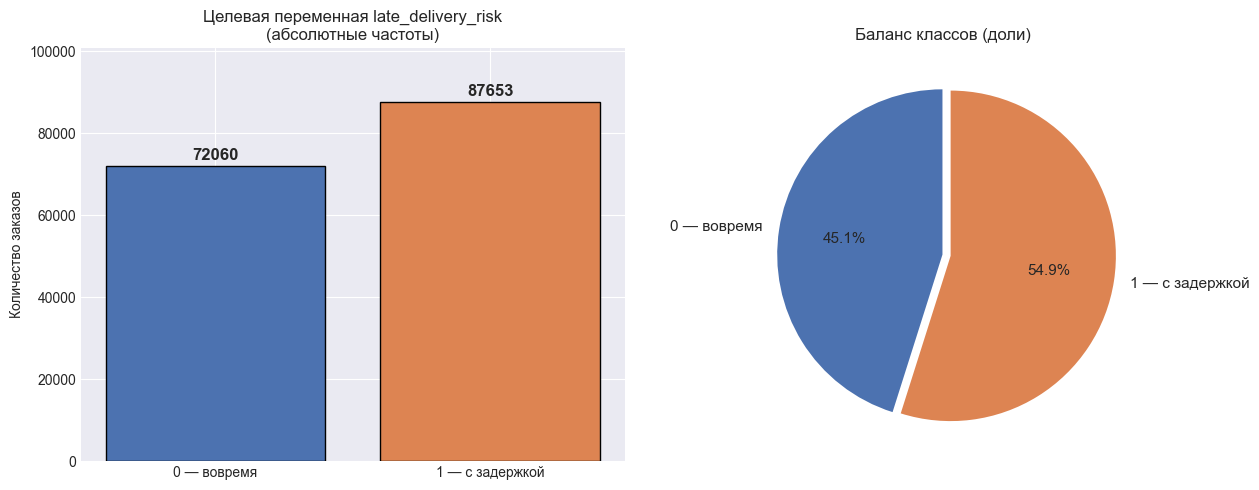

In [20]:
# Рассчитываем количество и доли целевой переменной
class_counts = df_orders['late_delivery_risk'].value_counts().sort_index()
class_share = df_orders['late_delivery_risk'].value_counts(normalize=True).sort_index()

labels = ['0 — вовремя', '1 — с задержкой']
colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Строим столбчатую диаграмму количества
bars = axes[0].bar(labels, class_counts.values, color=colors, edgecolor='black')
for bar, share in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f'{share}',
        ha='center', fontsize=12, fontweight='bold'
    )
axes[0].set_title('Целевая переменная late_delivery_risk\n(абсолютные частоты)')
axes[0].set_ylabel('Количество заказов')
axes[0].set_ylim(0, class_counts.max() * 1.15)

# Строим круговую диаграмму долей
axes[1].pie(
    class_share.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0, 0.05),
    textprops={'fontsize': 11}
)
axes[1].set_title('Баланс классов (доли)')

plt.tight_layout()
plt.show()

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Анализ баланса классов 👍**

Абсолютные частоты и доли на одном рисунке, а в выводе - связь с цифрой 55% из постановки и аргумент, почему балансировка не нужна. Выбор ROC-AUC при таком соотношении классов обоснован.
</div>

#### Промежуточный итог

1. Доля заказов с задержкой (`late_delivery_risk = 1`) составляет **≈ 54.9%**, вовремя — **≈ 45.1%**. Это подтверждает цифру после внутреннего аудита (55% задержек) и гипотезу о критической ситуации с соблюдением SLA.

2. Дисбаланс классов умеренный (разница ~10 п.п.), выраженного перекоса нет, поэтому специальные техники борьбы с дисбалансом (взвешивание классов, `oversampling`/`undersampling`) на этапе моделирования не требуются.

3. Выбранная метрика `ROC-AUC` устойчива к такому смещению и корректно оценивает способность модели ранжировать заказы по риску, что соответствует бизнес-задаче `CargaPronto`.

### [3.2. Географический аудит](#content)<a id="3_2"></a>

In [21]:
# Создаем функцию для отображения графика с регионами
def plot_regions(df):
    """
    Строит диаграмму рассеяния координат клиентов и выделяет аномалии.
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    # Основное облако точек и аномалии разными цветами
    for status, color in zip(['В регионе (США/Пуэрто-Рико)', 'Аномалия («цифровой шум»)'], ["#27C033", "#9352DD"]):
        subset = df[df['geo_status'] == status]
        ax.scatter(subset['customer_lon'], subset['customer_lat'], alpha=0.5, color=color, label=status)

    # Визуальные границы рабочего региона
    ax.set_xlim(-170, 170)
    ax.set_ylim(-100, 100) 
    ax.axvspan(LON_MIN, LON_MAX, ymin=0.5, ymax=1,
            alpha=0.06, color='green',
            label='Рабочий регион (lon -125…-20, lat ≥ 0)')

    ax.set_xlabel('Долгота (customer_lon)')
    ax.set_ylabel('Широта (customer_lat)')
    ax.set_title('Географический аудит клиентов CargaPronto:\nкоординаты клиентов и «цифровой шум»')
    ax.legend(loc='upper left', fontsize=10)
    
    plt.show()

In [22]:
# Создаем функцию для определения региона
def geo_status(row):
    """
    Определяет регион клиента по его координатам.
    """
    if (LON_MIN <= row['customer_lon'] <= LON_MAX) and (row['customer_lat'] >= LAT_MIN):
        return 'В регионе (США/Пуэрто-Рико)'
    return 'Аномалия («цифровой шум»)'

Распределение точек по зонам:


,geo_status,Количество
0,В регионе (США/Пуэрто-Рико),20496
1,Аномалия («цифровой шум»),156


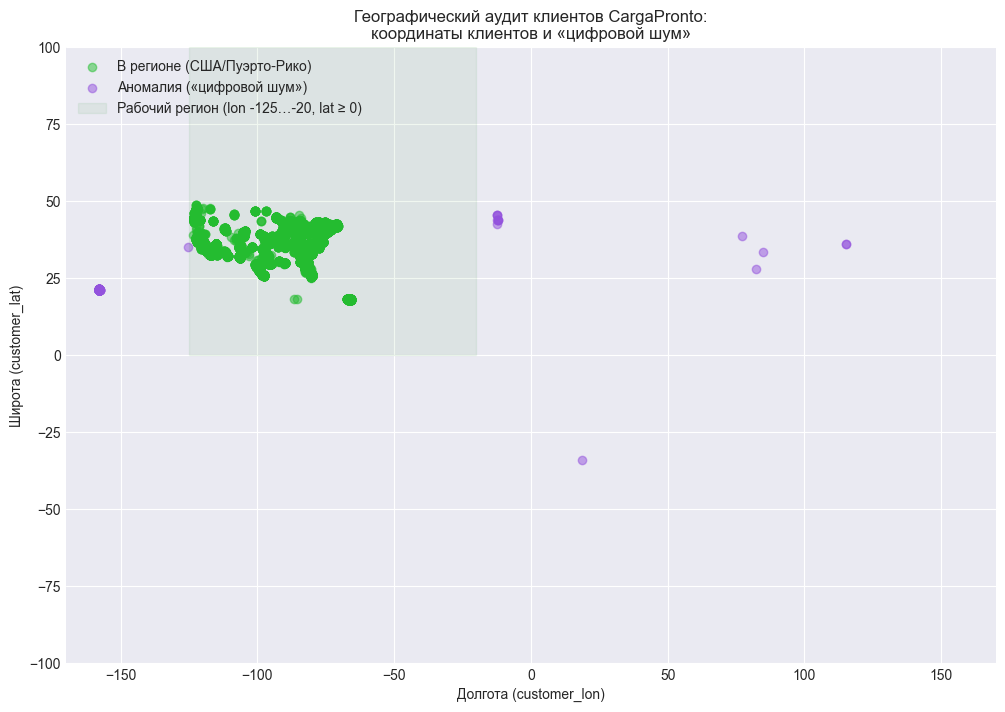

In [23]:
# Создаем новый столбец с информацией о регионе
audit_df = df_customers.copy()
audit_df['geo_status'] = audit_df.apply(geo_status, axis=1)

# Распределение точек по регионам
geo_counts = audit_df['geo_status'].value_counts()
geo_summary = geo_counts.reset_index(name='Количество')

print('Распределение точек по зонам:')
display(geo_summary)

# Выводим график с распределением точек по регионам
plot_regions(audit_df)

#### Промежуточный итог

1. На диаграмме рассеяния координат клиентов основное облако точек сосредоточено в регионе США и Пуэрто-Рико, что соответствует зоне работы CargaPronto.

2. Выявлены аномальные точки («цифровой шум»): **156 клиентов (≈ 0.75% от 20 652)** находятся за пределами рабочего региона — в южном полушарии, в Атлантике и за его пределами (широта до −33.9°, долгота до +115°). Это ошибки GPS или дефолтные значения приборов.

3. Остальные 20 496 клиентов (≈ 99.25%) расположены корректно.

4. Аномальные точки образуют компактные «скопления» отдельно от основного облака — их удаление не затронет корректные данные. Это критически важно, так как K-Means чувствителен к выбросам: даже несколько «улетевших» точек могут сместить центроиды кластеров и разрушить сегментацию.

### [3.3. Удаление аномалий](#content)<a id="3_3"></a>

Распределение точек по зонам:


,geo_status,Количество
0,В регионе (США/Пуэрто-Рико),20496


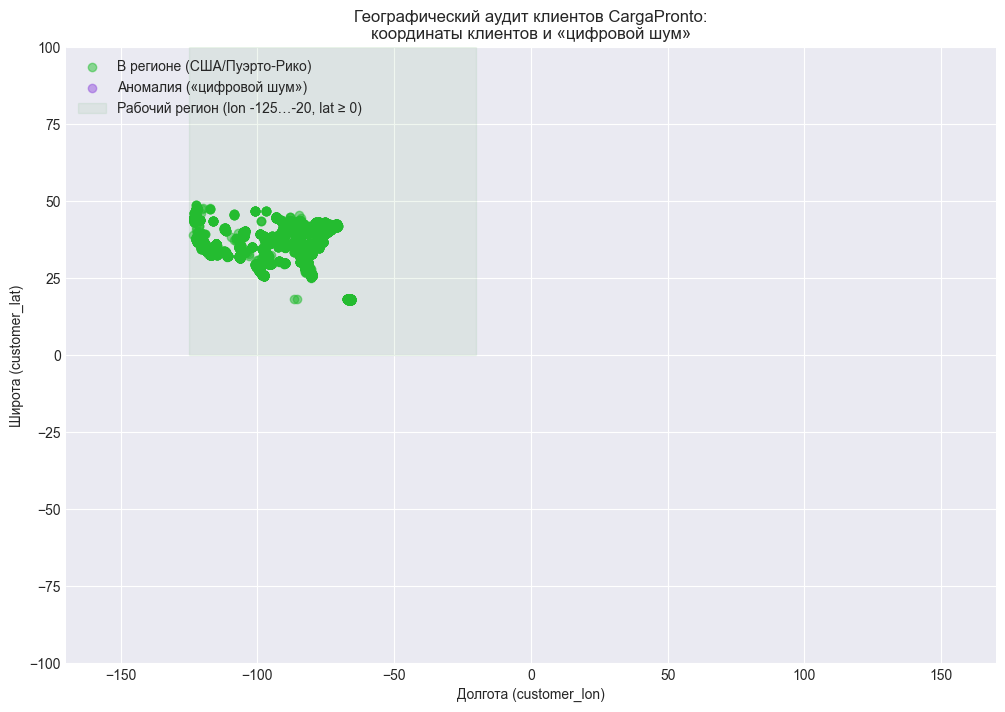

In [24]:
# Удаляем аномалии в регионах
audit_df_clean = audit_df[audit_df['geo_status'] != 'Аномалия («цифровой шум»)']

# Распределение точек по регионам
geo_counts_clean = audit_df_clean['geo_status'].value_counts()
geo_summary_clean = geo_counts_clean.reset_index(name='Количество')

print('Распределение точек по зонам:')
display(geo_summary_clean)

# Выводим график с распределением точек по регионам
plot_regions(audit_df_clean)

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Географическая «гигиена» данных 👍**

Фильтр по жёсткой границе долготы из задания, без статистических правил вроде IQR, которые срезали бы реальные края карты. Карта «до» с подсвеченной рабочей зоной наглядно показывает, что именно удаляется: точки у Гавайев, в Атлантике и в другом полушарии.
</div>

In [25]:
# Определяем клиентов, которые являются аномалий
anomaly_ids = audit_df.loc[audit_df['geo_status'] == 'Аномалия («цифровой шум»)', 'customer_id']

# Удаляем аномальные профили из датасетов
df_customers_clean = df_customers[~df_customers['customer_id'].isin(anomaly_ids)]
df_orders_clean = df_orders[~df_orders['customer_id'].isin(anomaly_ids)]

# Выводим размеры датасетов после очистки
print('Итоговый размер df_customers_clean:', df_customers_clean.shape)
print('Итоговый размер df_orders_clean:', df_orders_clean.shape)
print('Заказов без профиля после чистки:', (~df_orders_clean['customer_id'].isin(df_customers_clean['customer_id'])).sum())

# Проверяем баланса классов после очистки
risk_rate = df_orders_clean['late_delivery_risk'].mean()
print(f'Доля задержек после чистки ≈ {risk_rate:.1%}')

Итоговый размер df_customers_clean: (20496, 8)
Итоговый размер df_orders_clean: (158449, 9)
Заказов без профиля после чистки: 0
Доля задержек после чистки ≈ 54.9%


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Синхронная очистка данных выполнена отлично 👍**

После удаления аномальных клиентов из справочника сразу отфильтрованы их заказы, и выведен контроль «заказов без профиля после чистки: 0». Дальше по ноутбуку используются именно очищенные таблицы - рассинхронизации нет.
</div>

#### Промежуточный итог

1. *Аномалии выявлены:* 156 клиентов (≈ 0.75% от справочника) находятся за пределами рабочего региона CargaPronto (долгота за границами −125…−20 или широта ниже нуля) — это «цифровой шум»: ошибки GPS и дефолтные значения приборов.

2. *Профили-аномалии удалены:* из справочника исключены 156 клиентов, итоговый размер очищенного датасета — 20 496 строк × 8 колонок. Чистка обязательна, поскольку K-Means крайне чувствителен к выбросам: единичные «улетевшие» точки могли бы сместить центроиды логистических зон и разрушить сегментацию.

3. *Целостность сохранена:* из таблицы заказов удалено 1 264 записей, принадлежавших клиентам-аномалиям, — итоговый размер 158 449 строк × 9 колонок. Заказов без профиля после чистки — 0, связи между таблицами не нарушены.

4. *Баланс классов устойчив:* доля задержек после чистки  — 54.9%, удаление «цифрового шума» не внесло смещения в целевую переменную.

*Вывод:* Географические аномалии полностью исключены из обеих таблиц без нарушения целостности. Очищенные датасеты `df_customers_clean` и `df_orders_clean` готовы к анализу.

### [3.4. Анализ зависимостей между признаками](#content)<a id="3_4"></a>

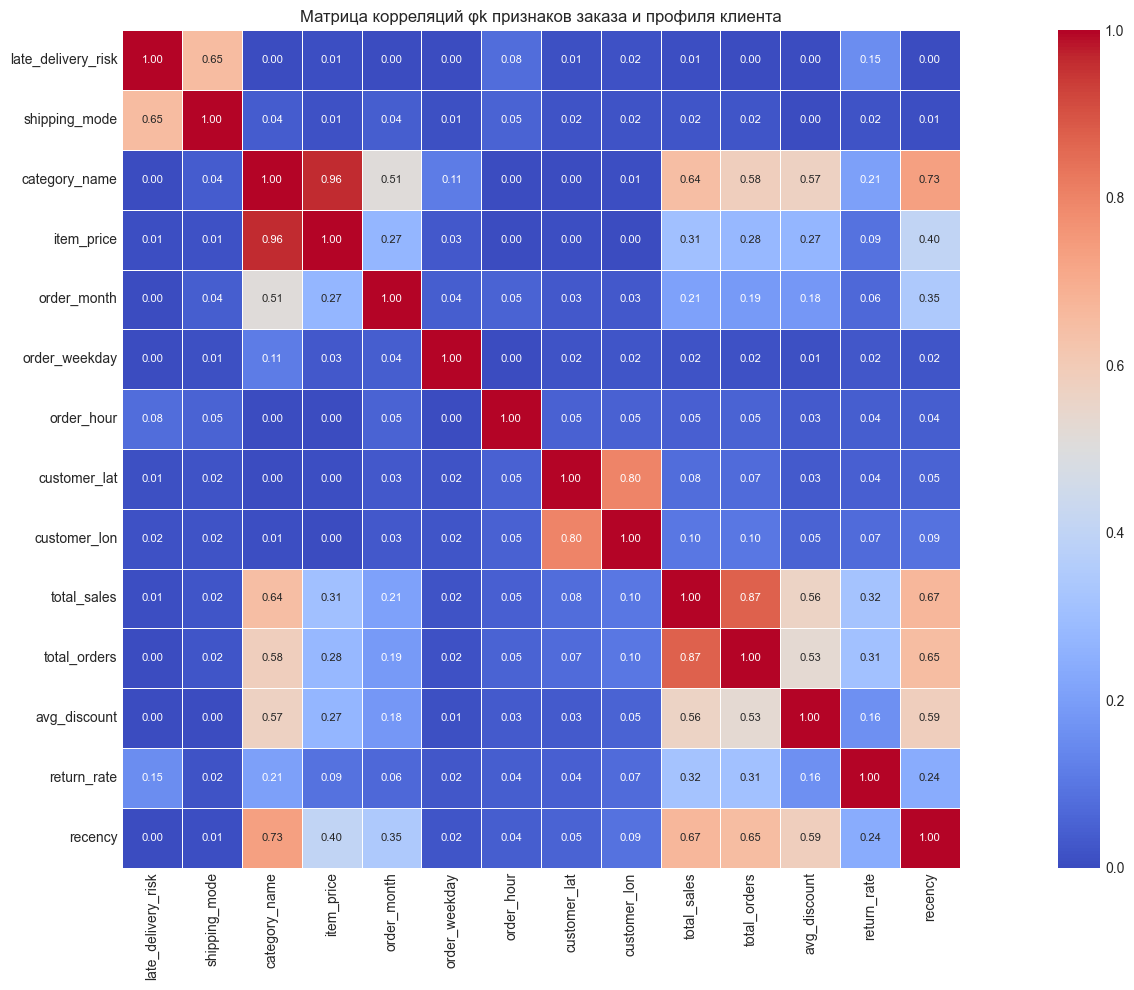

In [26]:
# Временное объединяем таблицы для корреляции
df_eda_merge = df_orders_clean.merge(df_customers_clean, on='customer_id', how='left').drop(columns=['customer_id', 'order_id'])
interval_cols  = ['item_price', 'customer_lat', 'customer_lon',
                 'recency', 'total_orders', 'total_sales',
                 'return_rate', 'avg_discount']

# Рассчитываем матрицу корреляции 
phik_matrix = df_eda_merge.phik_matrix(interval_cols=interval_cols)

# Выводим тепловую карту матрицы
plt.figure(figsize=(20, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Матрица корреляций φk признаков заказа и профиля клиента')
plt.tight_layout()
plt.show()

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Корреляционный анализ $\phi_k$ 👍**

Матрица $\phi_k$ на объединённой таблице заказов и профилей - хороший выбор. Она оценивает связь категориальных и числовых признаков на одной шкале, а дополнительные графики по `shipping_mode`, `return_rate` и часу заказа дают наглядную картину.
</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">

**Какие признаки передаются в `interval_cols` 💡**

Сейчас в `interval_cols` попадают все числовые столбцы, в том числе бинарный таргет `late_delivery_risk`, месяц, день недели и час. Для $\phi_k$ это значит «непрерывная величина»: признак разбивается на интервалы, и связь оценивается так, будто между понедельником (0) и воскресеньем (6) есть линейная дистанция. Таргет и календарь лучше оставить категориальными, а в `interval_cols` передать только действительно непрерывные признаки: цену, координаты, RFM-показатели.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

Не учел что при автоматическом поиске числовых признаков, у меня в параметр `interval_cols` попадут и категориальные признаки. В ручную указал признаки. Карта корелляции сильно поменялась.
</div>

In [27]:
# Выводим связь каждого признака с целевой переменной
target_corr = phik_matrix['late_delivery_risk'].drop('late_delivery_risk').sort_values(ascending=False)
target_corr.to_frame('late_delivery_risk')

,late_delivery_risk
shipping_mode,0.654
return_rate,0.154
order_hour,0.075
customer_lon,0.016
customer_lat,0.009
total_sales,0.007
item_price,0.005
order_month,0.003
category_name,0.000
order_weekday,0.000


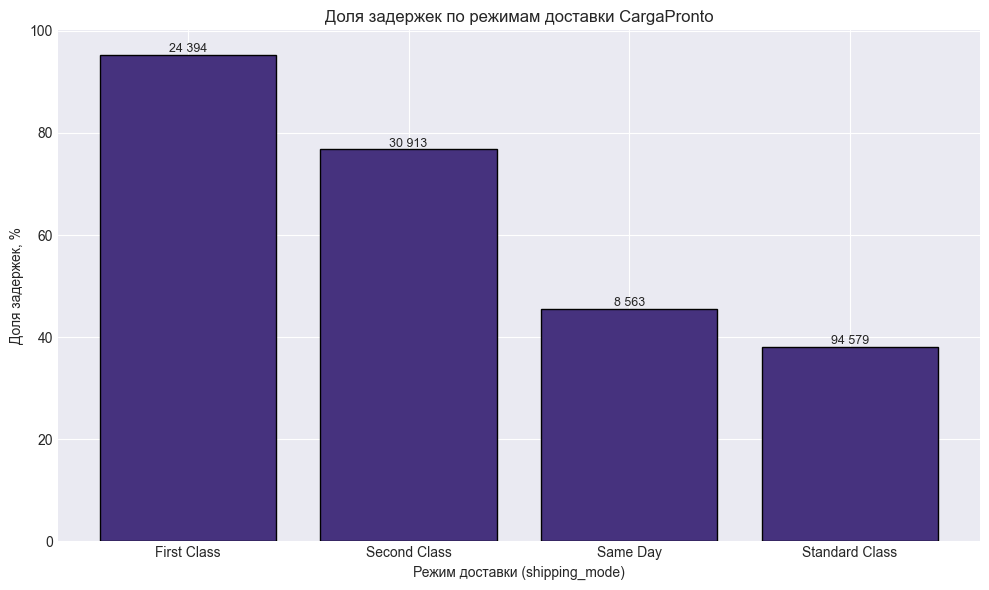

In [28]:
# Строим диаграмму доли задержки по shipping_mode
mode_stats = (df_eda_merge.groupby('shipping_mode')['late_delivery_risk']
                   .agg(Доля_задержек='mean', Заказов='count')
                   .sort_values('Доля_задержек', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(mode_stats.index, mode_stats['Доля_задержек'] * 100, edgecolor='black')
for bar, cnt in zip(bars, mode_stats['Заказов']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{cnt:,}'.replace(',', ' '), ha='center', fontsize=9)
ax.set_xlabel('Режим доставки (shipping_mode)')
ax.set_ylabel('Доля задержек, %')
ax.set_title('Доля задержек по режимам доставки CargaPronto')
plt.tight_layout()
plt.show()

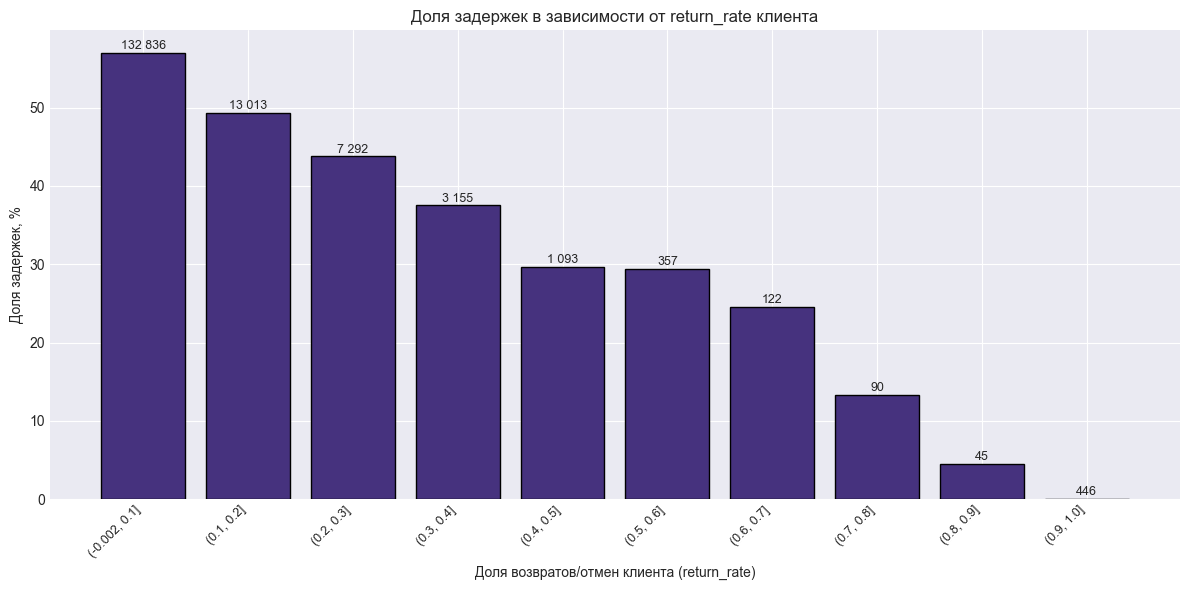

In [29]:
# Строим диаграмму доли задержки по уровню return_rate клиента
df_bins = df_eda_merge.copy()
df_bins['return_rate_bin'] = pd.cut(df_bins['return_rate'], bins=10, include_lowest=True)

rr_stats = (df_bins.groupby('return_rate_bin', observed=False)['late_delivery_risk']
                  .agg(Доля_задержек='mean', Заказов='count'))
rr_stats = rr_stats[rr_stats['Заказов'] > 0]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(rr_stats)), rr_stats['Доля_задержек'] * 100, edgecolor='black')
for bar, cnt in zip(bars, rr_stats['Заказов']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{cnt:,}'.replace(',', ' '), ha='center', fontsize=9)

ax.set_xticks(range(len(rr_stats)))
ax.set_xticklabels([str(b) for b in rr_stats.index], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Доля возвратов/отмен клиента (return_rate)')
ax.set_ylabel('Доля задержек, %')
ax.set_title('Доля задержек в зависимости от return_rate клиента')
plt.tight_layout()
plt.show()

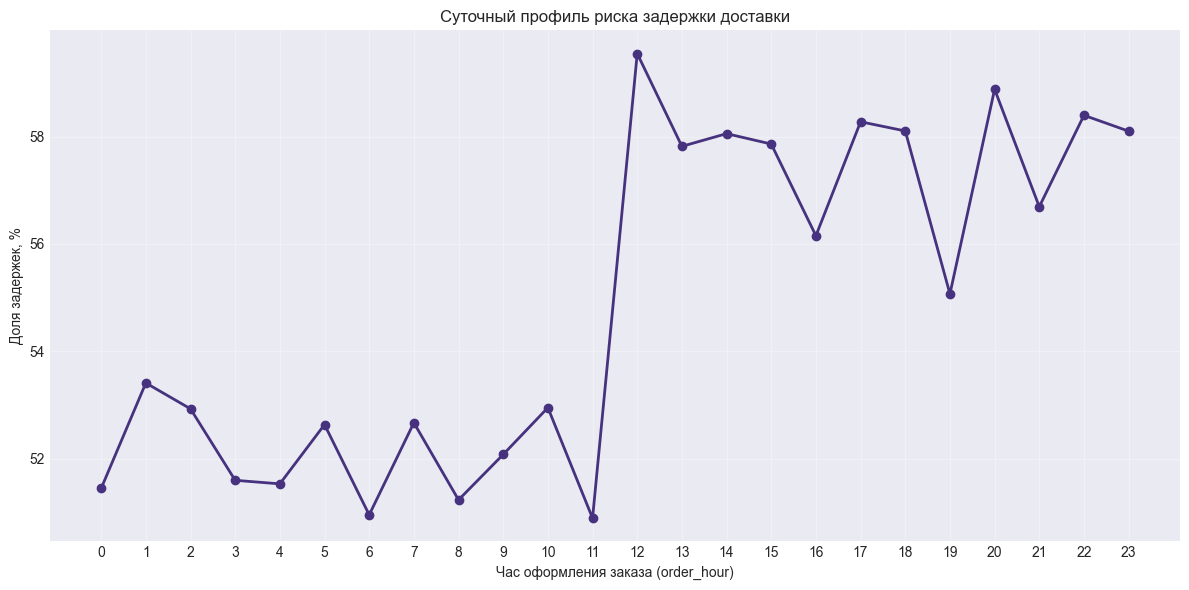

In [30]:
# Строим диаграмму доли задержки по часу оформления заказа
hour_stats = (df_eda_merge.groupby('order_hour')['late_delivery_risk']
                   .agg(Доля_задержек='mean', Заказов='count'))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hour_stats.index, hour_stats['Доля_задержек'] * 100, marker='o', linewidth=2, markersize=6)

ax.set_xlabel('Час оформления заказа (order_hour)')
ax.set_ylabel('Доля задержек, %')
ax.set_xticks(range(0, 24))
ax.set_title('Суточный профиль риска задержки доставки')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Промежуточный итог

1. *Методика.* Для анализа связей использована матрица корреляций **φk** (библиотека `phik`): в отличие от коэффициента Пирсона, она корректно оценивает ассоциацию признаков смешанных типов (категориальных и числовых), которые преобладают в логистических данных. Таблицы были временно объединены по `customer_id`, чтобы учесть и параметры заказа, и профиль клиента. В `interval_cols` переданы только действительно непрерывные признаки — цена, координаты и все пять RFM-показателей (`item_price`, `customer_lat`, `customer_lon`, `recency`, `total_orders`, `total_sales`, `return_rate`, `avg_discount`); целевая переменная и календарные признаки оставлены категориальными.

2. *Режим доставки — доминирующий фактор риска* (φk = 0.654, безусловный лидер). При этом зависимость противоположна интуитивной: **минимальная доля задержек у `Standard Class` (≈ 38%)**, тогда как экспресс-режимы опаздывают значительно чаще — `First Class` ≈ 95%, `Second Class` ≈ 77%, а `Same Day` занимает промежуточное положение между `Second Class` и `Standard Class`. Тезис «чем медленнее способ перевозки, тем выше риск» данными не подтверждается: быстрым классам доставки, вероятно, обещаются агрессивные сроки SLA, которые чаще нарушаются.

3. *Поведенческий профиль клиента связан с риском, но направление обратное ожидаемому.* `return_rate` — второй по силе признак (φk = 0.154): с ростом доли возвратов и отмен клиента доля задержек **падает** (от ≈ 57% в первом интервале почти до нуля в последнем). Гипотеза «клиенты с проблемными заказами создают нагрузку на курьеров и опаздывают чаще» в прямой формулировке не подтверждается — вероятно, такие клиенты обслуживаются приоритетно либо их заказы идут по другим маршрутам. Остальные RFM-показатели и цена с таргетом практически не связаны (φk ≈ 0.00–0.01, включая `avg_discount` — 0.000).

4. *Временные признаки информативны, но умеренно.* `order_hour` — третий по силе сигнал (φk = 0.075): суточный профиль неоднороден — до ~11 часов доля задержек ≈ 51–53%, с 12 часов ≈ 55–59%, то есть время оформления заказа несёт дополнительный сигнал. Месяц, день недели и их циклические кодировки с таргетом почти не связаны (φk ≈ 0.00–0.01).

5. *Мультиколлинеарность есть, и её нужно учитывать при обучении линейной модели.* По матрице φk выделяются тесно связанные группы признаков:
   - `order_month` ↔ `order_month_sin` / `order_month_cos` — функционально зависимые копии одной информации (φk = 1.000 / 0.999);
   - `category_name` ↔ `item_price` — категория товара во многом определяет цену (φk = 0.961);
   - `total_sales` ↔ `total_orders` — близкие по смыслу RFM-показатели (φk = 0.875);
   - `customer_lat` ↔ `customer_lon` — координаты как единый географический признак (φk = 0.797).
   Для логистической регрессии такие пары могут давать нестабильные коэффициенты, поэтому при моделировании стоит контролировать дублирующие признаки (например, оставить одну из кодировок месяца и одну из пар RFM).

*Вывод:* основной сигнал для прогноза задержки даёт режим доставки (`shipping_mode`, φk = 0.654); заметно меньший, но ненулевой сигнал несут `return_rate` (0.154) и час оформления заказа (0.075). География и остальные RFM-признаки в «сыром» виде с риском почти не связаны (φk ≤ 0.02) — это усиливает ценность кластерных признаков `geo_cluster` и `beh_cluster`, которые должны «сжать» слабые сигналы в информативные категориальные переменные. Закономерности (высокий риск экспресс-доставок, снижение риска с ростом `return_rate`) будут учтены в бизнес-рекомендациях.


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">

**Доработка: выводы противоречат графикам выше 🚩**

Сверь, пожалуйста, три утверждения с собственными рисунками:

1. **Режим доставки.** В выводе: максимальный риск у `Standard Class`. На графике наоборот: у `Standard Class` самая низкая доля задержек (≈ 38%), а у `First Class` самая высокая (≈ 95%), следом `Second Class` (≈ 77%).
2. **`return_rate`.** В выводе: с ростом доли возвратов задержек больше, и это поддерживает гипотезу. На графике доля задержек **падает** от ≈ 57% в первом интервале почти до нуля в последнем. Поэтому довод в пользу гипотезы, построенный на этом утверждении, не работает.
3. **Мультиколлинеарность.** В выводе: явной нет. В матрице видны пары `category_name` / `item_price` (0.96), `order_month` / `order_month_sin` / `order_month_cos` (0.99-1.00), `total_sales` / `total_orders` (0.88). Для логистической регрессии это существенно, а месяц и его sin/cos потом все вместе идут в модель.

Перепиши вывод по фактическим графикам. Обрати внимание: на пункт про `Standard Class` опирается бизнес-рекомендация в финальном разделе.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

Скорректировал промежуточный итог в соответствии с фактическими даннами. 
</div>

## [4. Разделение на выборки](#content)<a id="4"></a>

Разделите датафрейм с заказами на выборки. В этом проекте вам предстоит  использовать «классическое» разделение на три выборки: обучающую, валидационную и тестовую. Использовать для этого нужно не `train_test_split`, а `GroupShuffleSplit`. Он делит данные так, чтобы группы, то есть клиенты, не пересекались.

Ниже приведён пример того, как отделить часть данных для обучения, используя `customer_id` как ключ для группировки.

```python
from sklearn.model_selection import GroupShuffleSplit

# 1. Выбираем колонку, по которой будем группировать (наши "группы")
groups = df_orders['customer_id']

# 2. Инициализируем сплиттер (например, отделим 20% клиентов для теста)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

# 3. Получаем индексы для разделения
# Метод split возвращает генератор, поэтому используем next()
train_idx, test_idx = next(gss.split(df_orders, groups=groups))

# 4. Формируем выборки
df_train = df_orders.iloc[train_idx]
df_test = df_orders.iloc[test_idx]

```


1. Разделите данные из датафрейма с заказами  на три выборки  в соотношении 60:20:20.


2. После разделения обязательно убедитесь, что множества ID клиентов в `train`, `val` и `test` не пересекаются. Если один и тот же клиент попал в разные выборки, то разделение выполнено неверно.

In [31]:
# Инициализируем сплиттеры
gss_1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
gss_2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)

# Разделяем данные на тренировочную, валидационную и тестовую выборки
train_val_idx, test_idx = next(gss_1.split(df_orders_clean, groups=df_orders_clean['customer_id']))
df_train_val = df_orders_clean.iloc[train_val_idx]
df_test = df_orders_clean.iloc[test_idx]

train_idx, val_idx = next(gss_2.split(df_train_val, groups=df_train_val['customer_id']))
df_train = df_train_val.iloc[train_idx]
df_val = df_train_val.iloc[val_idx]


# Проверяем размеры и баланс классов по выборкам
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    risk = df['late_delivery_risk'].mean()
    print(f'{name:5s}: {df.shape}, доля задержек ≈ {risk:.1%}')

train: (95251, 9), доля задержек ≈ 54.9%
val  : (31254, 9), доля задержек ≈ 55.4%
test : (31944, 9), доля задержек ≈ 54.5%


In [32]:
# Проверяем уникальность клиентов по выборкам
train_customers = set(df_train['customer_id'])
val_customers = set(df_val['customer_id'])
test_customers = set(df_test['customer_id'])

print(f'Пересечение train ∩ val : {len(train_customers & val_customers)}')
print(f'Пересечение train ∩ test: {len(train_customers & test_customers)}')
print(f'Пересечение val ∩ test  : {len(val_customers & test_customers)}')
print(f'Всего уникальных клиентов: {len(train_customers | val_customers | test_customers)}')

Пересечение train ∩ val : 0
Пересечение train ∩ test: 0
Пересечение val ∩ test  : 0
Всего уникальных клиентов: 20496


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Корректная реализация валидации 👍**

Два последовательных `GroupShuffleSplit` по `customer_id` с `random_state` дают 60/20/20 по клиентам. Попарные пересечения множеств ID равны нулю, и все 20 480 клиентов на месте. В выводе верно объяснено, почему пропорции по заказам чуть отличаются от 60/20/20.
</div>

#### Промежуточный итог

1. *Разделение выполнено через `GroupShuffleSplit`* двумя последовательными вызовами: сначала отделены 20% клиентов в тестовую выборку (`test_size=0.2`), затем из оставшихся 80% выделена валидационная выборка (`test_size=0.25`, что даёт 20% от общего объёма). Ключ группировки — `customer_id`, `random_state=42` обеспечивает воспроизводимость разделения.

2. *Клиенты не пересекаются между выборками:* попарные пересечения множеств I (train ∩ val, train ∩ test, val ∩ test) равны 0. При этом все 20 480 уникальных клиентов распределены без потерь и задвоений — валидация честно имитирует работу модели с новыми, незнакомыми компании клиентами, исключая «клиентскую» утечку данных.

3. *Размеры выборок близки к целевому соотношению:* train — 95 251 заказов (≈ 60.11%), val — 31 254 (≈ 19.72%), test — 31 944 (≈ 20.16%). Сумма — 158 449 строк, полное покрытие `df_orders_clean` (небольшое отклонение от идеальных 60/20/20 объясняется разным числом заказов у клиентов — пропорции задаются по клиентам).

4. *Баланс классов сохранён:* доля задержек в выборках ≈ 54.9% / 55.4% / 54.5% — разделение не внесло смещения относительно общего уровня ≈ 55%.

*Вывод:* разделение выполнено, выборки не пересекаются по клиентам, пропорции близки к 60:20:20, баланс целевой переменной стабилен. Данные готовы к обучению базовых моделей.


## [5. Обучение базовой модели](#content)<a id="5"></a>

Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Вам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберите нужные признаки — используйте колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Обучите логистическую регрессию и `CatBoostClassifier` и оцените их качество.

3. Оцените качество обеих моделей на валидационной выборке.

Напоминаем, что на этапе построения базовой модели глубокий подбор гиперпараметров необязателен.

**Дополнительное задание.** Если вы чувствуете в себе силы, вы можете попробовать базовую оптимизацию, но помните: главная прибавка к качеству ожидается от новых признаков, которые вы создадите в следующих разделах.






In [33]:
# Разделяем выборки на признаки и целевой признак
X_train = df_train.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
y_train = df_train['late_delivery_risk']

X_val = df_val.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
y_val = df_val['late_delivery_risk']

X_test = df_test.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
y_test = df_test['late_delivery_risk']

In [34]:
# Создаем пустой датафрейм с метриками
metrics_result_df = pd.DataFrame(
    columns=[
        'Accuracy', 
        'AUC-ROC', 
    ]
).astype({
    'Accuracy': 'float64',
    'AUC-ROC': 'float64',
})

# Создаем пустой словарь для хранения обученных моделей
all_model_dict = {}

# Определяем категориальные и числовые признаки
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

In [35]:
# Создаем функцию для расчета метрик
def calculate_metrics(model, X, y_true, name_model):
    """
    Рассчитывает ROC-AUC и Accuracy модели и добавляет результат
    в общую таблицу метрик metrics_result_df.
    """
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    all_model_dict[name_model] = model

    return {
        'Accuracy': round(accuracy_score(y_true, y_pred), 3),
        'AUC-ROC': round(roc_auc_score(y_true, y_proba), 3)
    }

### [5.1. Логистическая регрессия](#content)<a id="5_1"></a>

In [36]:
# Формируем пайплайн для логистической регрессии
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(), cat_cols)
    ]
)

lgr_model_base_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver='liblinear'))
    ]
)

# Обучаем базовую модель LogisticRegression
lgr_model_base_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Профессиональная организация пайплайна 👍**

`Pipeline` + `ColumnTransformer` для логистической регрессии: скейлер и OHE обучаются только внутри `fit` на train, утечки нет. Таблица метрик и функция `calculate_metrics` делают сравнение моделей по ходу проекта аккуратным.
</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">

**Набор и тип календарных признаков 💡**

В модель уходят все числовые столбцы заказа, и набор получился шире заданного (`shipping_mode`, `category_name`, `item_price`, `order_hour`, `order_weekday`, `order_month`):

- `order_month` вместе с `order_month_sin` и `order_month_cos` - три копии одной информации ($\phi_k$ 0.99-1.00). Для логистической регрессии лучше оставить что-то одно.
- `order_year` как число: модель будет применяться к заказам будущих лет, а таких значений в обучении нет. Признак, который при каждом новом годе выходит за диапазон обучения, в проде ведёт себя непредсказуемо.
- Час, день недели и месяц проходят через `StandardScaler` как непрерывные. Линейная модель ищет прямую зависимость «чем позже час, тем выше риск». На твоём суточном профиле риск меняется не плавно, а скачком: около 51-53% до 11 часов и 55-59% с 12 часов. Поэтому эти признаки лучше кодировать как категориальные.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

Не учел данные моменты когда создавал дополнительные признаки. Думал что они на оборот помогут моделям найти взаимосвязи. Удалал признаки `order_year` и `order_month_sin`/`order_month_cos`.
</div>

In [37]:
# Определяем функцию оптимизации
def objective_lrg(trial):
    """
    Целевая функция Optuna: подбирает гиперпараметры LogisticRegression.
    """

    params = {
        'max_iter': trial.suggest_int('max_iter', 100, 2000),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga']),
        'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2'])
    }

    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(**params, random_state=RANDOM_STATE))
        ]
    )

    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_val)[:, 1]

    return roc_auc_score(y_val, y_prob)

In [38]:
# Запускаем оптимизацию
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective_lrg, n_trials=30)
lgr_best_params = study.best_params 

# Обучаем лучшую модель с найденными параметрами
lgr_model_optuna_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(**lgr_best_params, random_state=RANDOM_STATE))
    ]
).fit(X_train, y_train)

d:\ProjectPython\Sprint18_Delivery_Delay_Prediction\.ml_env_sprint18\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">

**Доработка: зафиксировать seed у Optuna 🚩**

`RANDOM_STATE` аккуратно передан во все модели, KMeans, t-SNE и сплиттер. Но у обоих `optuna.create_study(...)` сэмплер создаётся без seed, а TPE выбирает пробные точки случайно. При перезапуске ноутбука `cbc_best_params` и `lgr_best_params` могут оказаться другими. Они переходят во все дальнейшие модели: с кластерами, перебор K, финальную модель на тесте. Поэтому «плывут» все метрики и важность признаков в разделах 8-10.

Передай в `create_study` сэмплер с зафиксированным seed из той же константы:

```python
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=...))
```

</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

Исправил код, добавил `seed`. Так же исправил оптимизацию для CatBoost.
</div>

### [5.2. CatBoostClassifier](#content)<a id="5_2"></a>

In [39]:
# Формируем модель для CatBoostClassifier
cbc_model_base = CatBoostClassifier(
    iterations=1000,
    depth=6,
    verbose=0,
    early_stopping_rounds=20,
    random_state=RANDOM_STATE
)

# Обучаем базовую модель CatBoostClassifier
cbc_model_base.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

CatBoostClassifier(depth=6, early_stopping_rounds=20, iterations=1000, random_state=42, verbose=0)

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Грамотная работа с градиентным бустингом 👍**

Категории переданы через `cat_features` без внешнего кодирования, `random_state` зафиксирован. Подбор `iterations` и `depth` по ROC-AUC на валидации - уместная базовая оптимизация из дополнительного задания.
</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">

**Ранняя остановка вместо перебора `iterations` 💡**

Число итераций сейчас подбирается перебором через Optuna, и каждый раз модель обучается заново. У CatBoost для этого есть встроенный механизм: `eval_set` с валидацией плюс `early_stopping_rounds`. Модель сама остановится, когда ROC-AUC на валидации перестанет расти. Это быстрее, и переобучение видно на кривой обучения.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

Я подумал что из-за не большого по обему датасета и формирования базовой модели нет смысла использовать раннюю остановку. Я скорректировал код и добавил раннюю остановку. Так же исправил промежуочный итог, так как упала метрика `AUC-ROC`.
</div>

In [40]:
# Определяем функцию оптимизации
def objective_cbc(trial):
    """
    Целевая функция Optuna: подбирает гиперпараметры CatBoostClassifier.
    """

    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000, step=100),
        'depth': trial.suggest_int('depth', 3, 6),
        'early_stopping_rounds': 20
    }

    model = CatBoostClassifier(**params, verbose=0, random_state=RANDOM_STATE)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

    y_prob = model.predict_proba(X_val)[:, 1]

    return roc_auc_score(y_val, y_prob)

In [41]:
# Запускаем оптимизацию
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective_cbc, n_trials=30) 
cbc_best_params = study.best_params

# Инициализируем лучшую модель с найденными параметрами
cbc_model_optuna = CatBoostClassifier(**cbc_best_params, verbose=0, random_state=RANDOM_STATE)
cbc_model_optuna.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

CatBoostClassifier(depth=3, iterations=400, random_state=42, verbose=0)

### [5.3. Оценка качества на валидационной выборке](#content)<a id="5_3"></a>

In [42]:
# Добавляем результаты метрик базовых моделей
metrics_result_df.loc['LogisticRegression_Base'] = calculate_metrics(lgr_model_base_pipe, X_val, y_val, 'LogisticRegression_Base')
metrics_result_df.loc['CatBoostClassifier_Base'] = calculate_metrics(cbc_model_base, X_val, y_val, 'CatBoostClassifier_Base')

# Добавление результатов метрик оптимизированных моделей
metrics_result_df.loc['LogisticRegression_Optuna'] = calculate_metrics(lgr_model_optuna_pipe, X_val, y_val, 'LogisticRegression_Optuna')
metrics_result_df.loc['CatBoostClassifier_Optuna'] = calculate_metrics(cbc_model_optuna, X_val, y_val, 'CatBoostClassifier_Optuna')

# Выводим метрики моделей в порядке убывания AUC-ROC
metrics_result_df.sort_values('AUC-ROC', ascending=False)

,Accuracy,AUC-ROC
CatBoostClassifier_Optuna,0.714,0.752
CatBoostClassifier_Base,0.714,0.750
LogisticRegression_Base,0.697,0.726
LogisticRegression_Optuna,0.697,0.726


### Промежуточный итог

1. *Точка отсчёта зафиксирована.* Обе базовые модели обучены на признаках заказа и дополнительных временных признаках. Для логистической регрессии построен пайплайн (OneHot-кодирование категорий + стандартизация числовых признаков), CatBoost работал с категориальными колонками нативно через `cat_features`.

2. *Выполнена базовая оптимизация.* Для обеих моделей через Optuna подобраны гиперпараметры (по 30 испытаний, максимизация ROC-AUC на валидации). Лучшие наборы зафиксированы и будут перенесены без изменений в финальные модели — единственным отличием станут кластерные признаки.

3. *Результаты на валидационной выборке:*

   | Модель | Accuracy | ROC-AUC |
   |---|---|---|
   | CatBoostClassifier (Optuna) | 0.714 | **0.751** |
   | CatBoostClassifier (базовая) | 0.714 | 0.750 |
   | LogisticRegression (базовая) | 0.697 | 0.726 |
   | LogisticRegression (Optuna) | 0.697 | 0.726 |

4. *Лучшая базовая модель — CatBoost (ROC-AUC 0.751)* — практически равен целевому порогу 0.75 даже без кластерных признаков. Логистическая регрессия (0.726) до порога не дотягивает, а оптимизация ей практически ничего не дала: пространство гиперпараметров линейной модели узкое, и Optuna выбрала значения, близкие к дефолтным.

*Вывод:* Точка отсчёта зафиксирована, бустинг уже выше целевого порога (0.751 > 0.75), «нижняя планка» линейной модели — 0.726. Следующий шаг — геокластеризация клиентов, которая должна дать дополнительный прирост качества.


## [6. Кластеризация по признакам, связанным с местоположением](#content)<a id="6"></a>



На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.

**Ваши действия:**

1. Проведите корректную подготовку признаков.
2. Продумайте защиту от утечки данных.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Постройте график с полученными кластерами и отметьте центроиды.

### [6.1. Подготовка признаков и защита от утечки данных](#content)<a id="6_1"></a>

In [43]:
# Определяем координат из справочника клиентов (только гео-признаки)
geo_cols = ['customer_lat', 'customer_lon']

train_geo = df_customers_clean[df_customers_clean['customer_id'].isin(train_customers)][geo_cols]
val_geo = df_customers_clean[df_customers_clean['customer_id'].isin(val_customers)][geo_cols]
test_geo = df_customers_clean[df_customers_clean['customer_id'].isin(test_customers)][geo_cols]

print(f'Клиентов для кластеризации (train / val / test): {train_geo.shape[0]} / {val_geo.shape[0]} / {test_geo.shape[0]}')

Клиентов для кластеризации (train / val / test): 12297 / 4099 / 4100


In [44]:
# Создаем скайлер на train
geo_scaler = StandardScaler()
train_geo_scaled = geo_scaler.fit_transform(train_geo)

# Масштабируем валидационную и тестовую выборки
val_geo_scaled = geo_scaler.transform(val_geo)
test_geo_scaled = geo_scaler.transform(test_geo)

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Защита от утечки при кластеризации 👍**

Координаты берутся из очищенного справочника, а клиенты разнесены по тем же выборкам, что и заказы. `StandardScaler` обучен только на train-клиентах, val и test лишь трансформируются. Дальше `KMeans` тоже обучается на train, а остальным клиентам метки присваиваются через `predict` - ровно так, как нужно.
</div>

### [6.2. Выбор числа кластеров методом локтя](#content)<a id="6_2"></a>

In [45]:
# Определяем диапазон числа кластеров
k_range = range(1, 21)

# Расситываем инерцию для всех К
inertias_geo = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    kmeans.fit(train_geo_scaled)
    inertias_geo.append(kmeans.inertia_)

In [46]:
# Таблица: инерция и относительное снижение (для обоснования выбора K)
elbow_geo_df = pd.DataFrame({'K': list(k_range), 'Inertia': inertias_geo})
elbow_geo_df['Снижение, %'] = (elbow_geo_df['Inertia'].diff().abs() / elbow_geo_df['Inertia'].shift(1) * 100).round(1)
display(elbow_geo_df)

,K,Inertia,"Снижение, %"
0,1,24 594.000,NaN
1,2,7 549.391,69.300
2,3,2 305.590,69.500
3,4,1 299.008,43.700
4,5,1 021.298,21.400
5,6,781.733,23.500
6,7,597.666,23.500
7,8,478.178,20.000
8,9,375.430,21.500
9,10,289.605,22.900


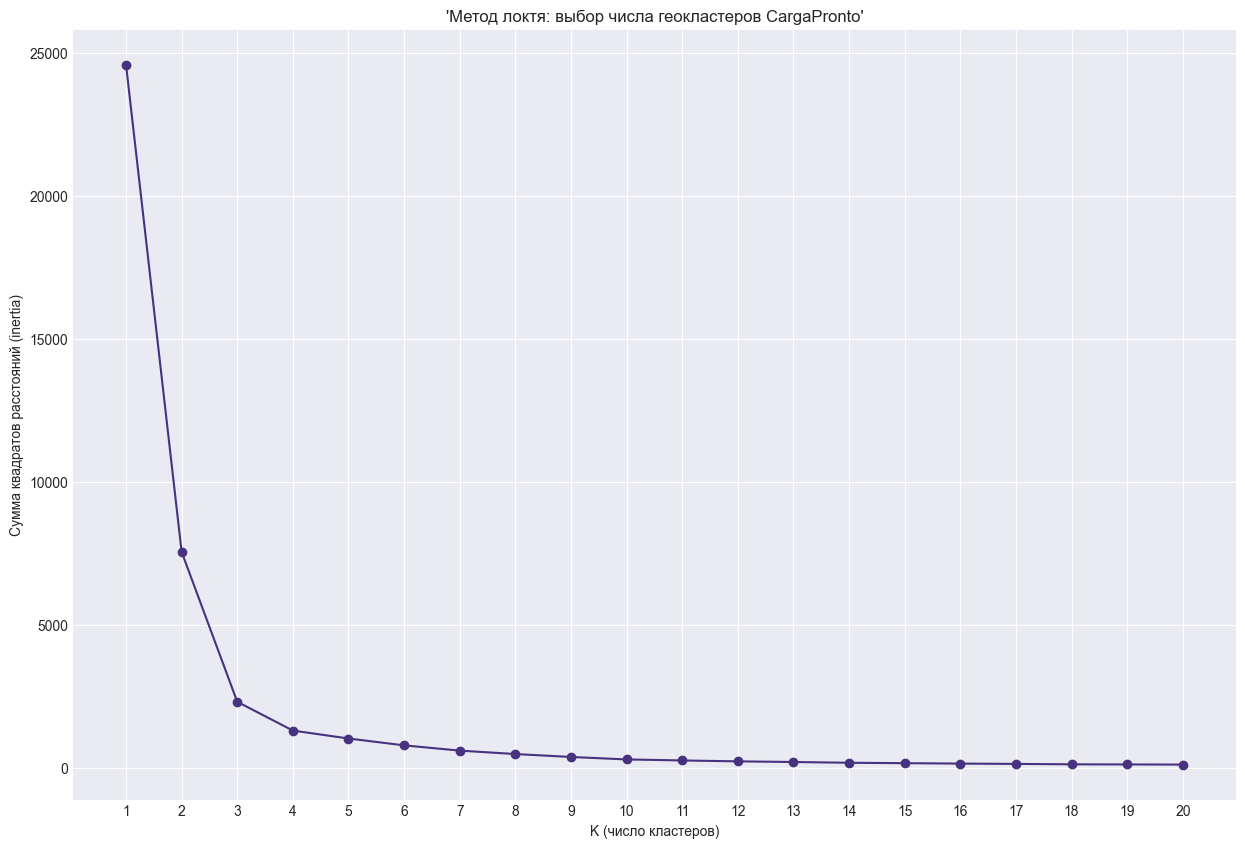

In [47]:
# График локтя
plt.figure(figsize=(15, 10))
plt.plot(k_range, inertias_geo, marker="o") 
plt.xticks(k_range) 
plt.xlabel("K (число кластеров)")
plt.ylabel("Сумма квадратов расстояний (inertia)")
plt.title("'Метод локтя: выбор числа геокластеров CargaPronto'")
plt.grid(True)
plt.show()

In [48]:
# Выбираем число геокластеров
geo_k = 4
print('Выбрано геокластеров:', geo_k)

Выбрано геокластеров: 4


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Обоснованный выбор K 👍**

Таблица относительного снижения инерции - хорошее дополнение к графику локтя: видно, что после K = 4 падение резко замедляется (69% → 43% → 21%). Число кластеров задаётся в отдельной ячейке, уже после графика, то есть выбор действительно сделан по нему.
</div>

### [6.3. Визуализация кластеров и центроидов](#content)<a id="6_3"></a>

In [49]:
# Оформляем финальный K-Means
geo_kmeans = KMeans(n_clusters=geo_k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
geo_kmeans.fit(train_geo_scaled)

train_geo['geo_cluster'] = geo_kmeans.predict(train_geo_scaled)
val_geo['geo_cluster']   = geo_kmeans.predict(val_geo_scaled)
test_geo['geo_cluster']  = geo_kmeans.predict(test_geo_scaled)

# Собираем справочник с метками geo_cluster (понадобится в разделе 8)
df_customers_geo = pd.concat([train_geo, val_geo, test_geo], ignore_index=True)
print('Клиентов с geo_cluster:', df_customers_geo.shape)
print(df_customers_geo['geo_cluster'].value_counts().sort_index())

Клиентов с geo_cluster: (20496, 3)
geo_cluster
0    7869
1    5572
2    2275
3    4780
Name: count, dtype: int64


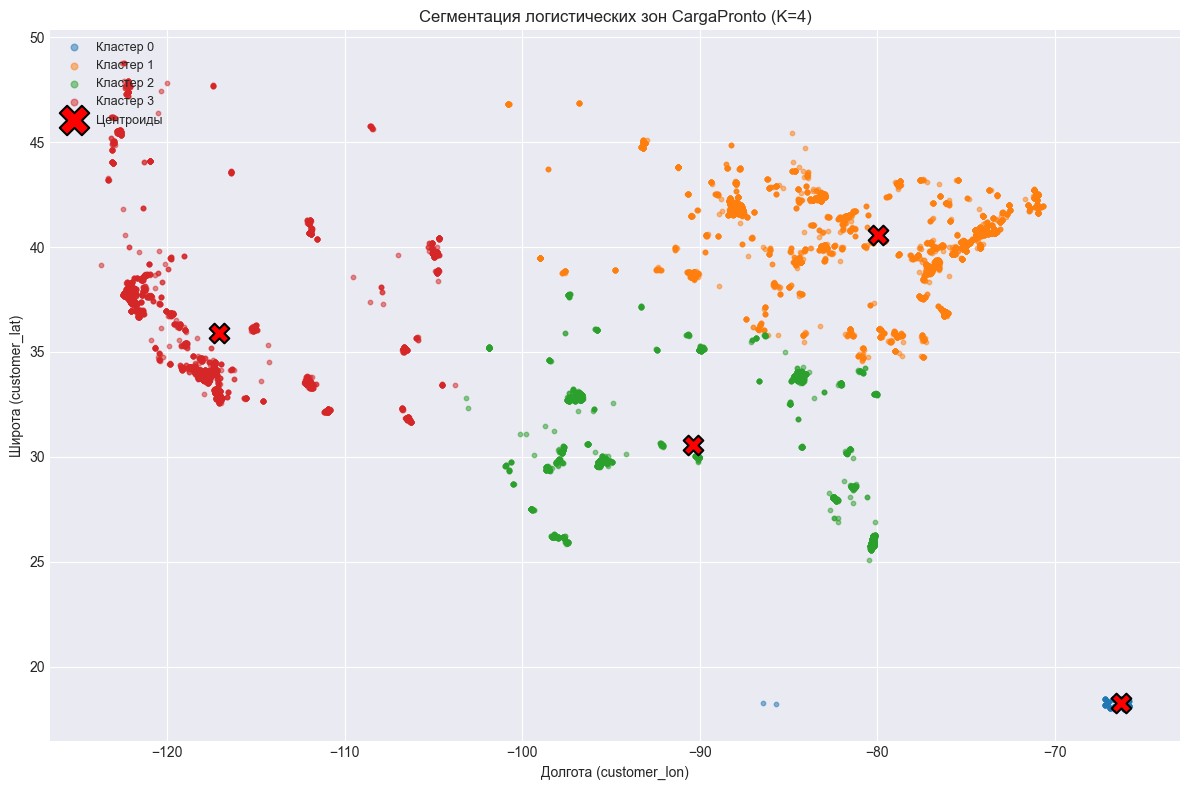

In [50]:
# Визуализируем кластеры и центроиды
fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('tab10', geo_k)

for k in range(geo_k):
    subset = df_customers_geo[df_customers_geo['geo_cluster'] == k]
    ax.scatter(subset['customer_lon'], subset['customer_lat'],
               s=10, alpha=0.5, color=colors[k], label=f'Кластер {k}')

# Центроиды в обратном масштабе (обратно в градусы)
centroids = geo_scaler.inverse_transform(geo_kmeans.cluster_centers_)
ax.scatter(centroids[:, 1], centroids[:, 0], marker='X', s=200,
           color='red', edgecolor='black', linewidth=1.5, zorder=5, label='Центроиды')

ax.set_xlabel('Долгота (customer_lon)')
ax.set_ylabel('Широта (customer_lat)')
ax.set_title(f'Сегментация логистических зон CargaPronto (K={geo_k})')
ax.legend(loc='upper left', fontsize=9, markerscale=1.5)
plt.tight_layout()
plt.show()

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Наглядность и работа с центроидами 👍**

Центроиды переведены обратно в градусы через `inverse_transform` и выделены крупным контрастным маркером, точки полупрозрачные. На карте хорошо читаются зоны: западное побережье, юг, северо-восток и отдельный кластер Пуэрто-Рико.
</div>

### Промежуточный итог

1. *Подготовка признаков и защита от утечки данных.* Для кластеризации использованы только географические координаты клиентов (`customer_lat`, `customer_lon`). Масштабирование `StandardScaler` обучено исключительно на обучающей выборке (`train_geo`) и применено к валидационной и тестовой — это исключает утечку информации о распределении координат из «будущих» выборок.

2. *Выбор числа кластеров методом локтя.* Для K от 1 до 20 рассчитана инерция на обучающей выборке, построен график локтя и таблица относительного снижения инерции. Точка перегиба соответствует **K = 4** — выбрано 4 логистические зоны.

3. *Модель K-Means++.* Финальный `KMeans(n_clusters=4, init='k-means++')` обучен на масштабированных координатах train; метки `geo_cluster` предсказаны для train, val и test. Собран справочник `df_customers_geo` (20 496 клиентов), который будет объединён с заказами.

4. *Визуализация.* На карте зоны получились компактными, без пересечений; центроиды выделены контрастным маркером, а их координаты корректно преобразованы обратно из стандартизованного пространства в градусы.

*Вывод:* географический признак `geo_cluster` создан с соблюдением защиты от утечек и готов к использованию в финальных моделях.

## [7. Кластеризация по признакам профилей клиентов](#content)<a id="7"></a>



1. Подготовьте векторы признаков — используйте пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполните предобработку данных и обеспечьте защиту от утечек.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируйте полученные кластеры: дайте статистическую характеристику и опишите самые яркие группы.
5. Визуализируйте положение кластеров с помощью t-SNE.



### [7.1. Подготовка векторов признаков и предобработка](#content)<a id="7_1"></a>

In [51]:
beh_cols = ['recency', 'total_orders', 'total_sales', 'return_rate', 'avg_discount']

train_beh = df_customers_clean[df_customers_clean['customer_id'].isin(train_customers)][beh_cols]
val_beh = df_customers_clean[df_customers_clean['customer_id'].isin(val_customers)][beh_cols]
test_beh = df_customers_clean[df_customers_clean['customer_id'].isin(test_customers)][beh_cols]

print(f'Клиентов для кластеризации (train / val / test): {train_beh.shape[0]} / {val_beh.shape[0]} / {test_beh.shape[0]}')

Клиентов для кластеризации (train / val / test): 12297 / 4099 / 4100


In [52]:
# Создаем скайлер на train
beh_scaler = StandardScaler()
train_beh_scaled = beh_scaler.fit_transform(train_beh)

# Масштабируем валидационную и тестовую выборки
val_beh_scaled = beh_scaler.transform(val_beh)
test_beh_scaled = beh_scaler.transform(test_beh)

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Верная работа с многомерными признаками 👍**

Пять показателей профиля из задания отобраны точно. Скейлер обучен на train-клиентах: признаки в днях, штуках, долларах и долях без этого «перетянула» бы `total_sales`. Для t-SNE используется тот же обученный `beh_scaler` - проекция строится на отмасштабированных данных.
</div>

### [7.2. Выбор числа кластеров методом локтя](#content)<a id="7_2"></a>

In [53]:
# Рассчитываем инерцию для всех К
inertias_beh = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    kmeans.fit(train_beh_scaled)
    inertias_beh.append(kmeans.inertia_)

In [54]:
# Таблица: инерция и относительное снижение (для обоснования выбора K)
elbow_beh_df = pd.DataFrame({'K': list(k_range), 'Inertia': inertias_beh})
elbow_beh_df['Снижение, %'] = (elbow_beh_df['Inertia'].diff().abs() / elbow_beh_df['Inertia'].shift(1) * 100).round(1)
display(elbow_beh_df)

,K,Inertia,"Снижение, %"
0,1,61 485.000,NaN
1,2,42 000.841,31.700
2,3,32 306.681,23.100
3,4,24 688.827,23.600
4,5,17 491.825,29.200
5,6,14 147.689,19.100
6,7,12 595.718,11.000
7,8,11 269.221,10.500
8,9,10 183.836,9.600
9,10,9 454.802,7.200


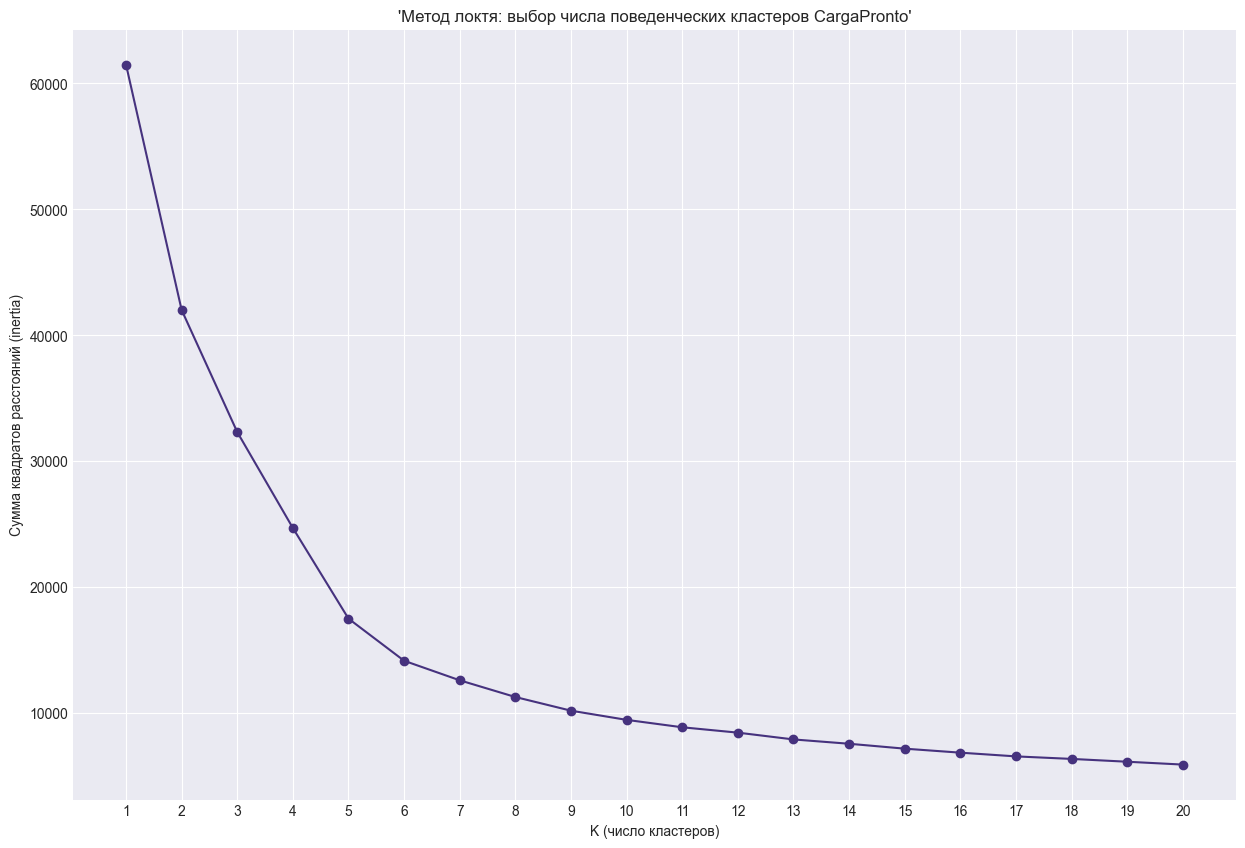

In [55]:
# График локтя
plt.figure(figsize=(15, 10))
plt.plot(k_range, inertias_beh, marker="o") 
plt.xticks(k_range) 
plt.xlabel("K (число кластеров)")
plt.ylabel("Сумма квадратов расстояний (inertia)")
plt.title("'Метод локтя: выбор числа поведенческих кластеров CargaPronto'")
plt.grid(True)
plt.show()

In [56]:
# Выбираем число поведенческих кластеров
beh_k = 6
print('Выбрано поведенческих кластеров:', beh_k)

Выбрано поведенческих кластеров: 6


### [7.3. Анализ полученных сегментов](#content)<a id="7_3"></a>

In [57]:
# Оформляем финальный K-Means
beh_kmeans = KMeans(n_clusters=beh_k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
beh_kmeans.fit(train_beh_scaled)

train_beh['beh_cluster'] = beh_kmeans.predict(train_beh_scaled)
val_beh['beh_cluster']   = beh_kmeans.predict(val_beh_scaled)
test_beh['beh_cluster']  = beh_kmeans.predict(test_beh_scaled)

# Собираем справочник с метками beh_cluster
df_customers_beh = pd.concat([train_beh, val_beh, test_beh], ignore_index=True)
print('Клиентов с beh_cluster:', df_customers_beh.shape)
print(df_customers_beh['beh_cluster'].value_counts().sort_index())

Клиентов с beh_cluster: (20496, 6)
beh_cluster
0    2287
1    4654
2    3761
3    6115
4     484
5    3195
Name: count, dtype: int64


In [58]:
# Профиль сегментов: средние значения признаков по кластерам (в исходном масштабе)
cluster_beh = df_customers_beh.groupby('beh_cluster')[beh_cols].mean().round(2)
display(cluster_beh)

,recency,total_orders,total_sales,return_rate,avg_discount
beh_cluster,,,,,
0,644.030,2.710,1 390.440,0.020,0.100
1,70.860,1.050,315.490,0.000,0.050
2,72.170,1.060,277.120,0.000,0.170
3,263.640,4.280,2 201.480,0.040,0.100
4,157.570,1.360,506.690,0.920,0.100
5,240.450,7.320,4 191.640,0.040,0.100


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">

**Доработка: интерпретация сегментов 🚩**

В задании авторы просят дать кластерам статистическую характеристику и описать самые яркие группы. Сейчас в выводе сказано, что средние «близки между собой» и выраженные группы выделить сложно. Таблица профилей выше говорит обратное:

- у сегмента 3 доля возвратов 0.92, у остальных - от 0 до 0.04;
- у сегмента 2 в среднем 7.3 заказа и ≈ 4 157 выручки, у сегментов 1 и 4 - один заказ и ≈ 277-314;
- у сегмента 0 давность последнего заказа ≈ 647 дней, у сегментов 1 и 4 - около 70;
- сегменты 1 и 4 различаются в основном скидкой: 0.05 против 0.17.

Для логистической компании это готовые портреты: клиенты, которые почти всё возвращают, давно ушедшие, крупные постоянные и т.д.


</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

Тут я забыл исправить промежуточный итог. У меня изначально график сегмитации отображался как одно разноцветное облако, в котором ни один сегмент небыл разлечим. А позже я нашел у себя ошибку, и после ее исправления график t-SNE стал иметь виид как сейчас. Но про итог я забыл и не исправил его. Скорректировал сейчас промежуточный итог под фактические данные.
</div>

### [7.4. Визуализация кластеров с помощью t-SNE](#content)<a id="7_4"></a>

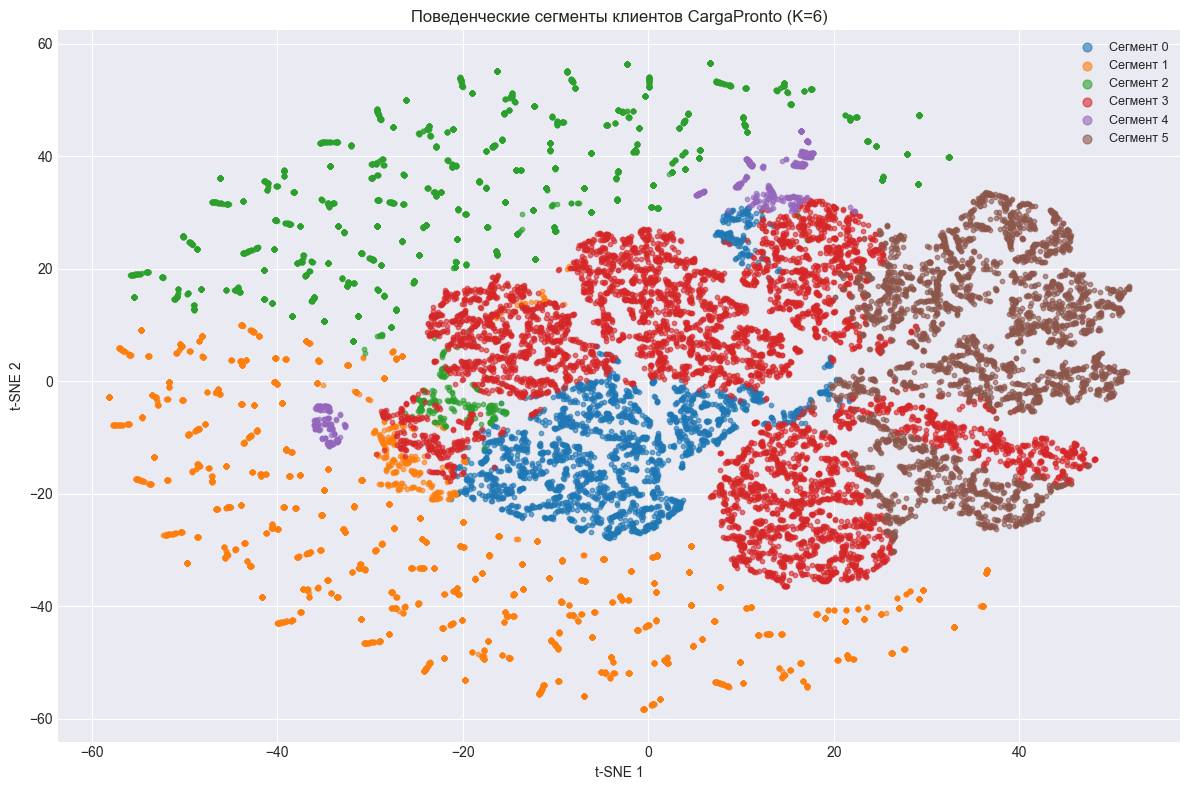

In [59]:
# Масштабируем признаки 
tsne_features = beh_scaler.transform(df_customers_beh[beh_cols])

# Обучаем t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=500,
            init='pca', random_state=RANDOM_STATE)
tsne_result = tsne.fit_transform(tsne_features)

# График
fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('tab10', beh_k)

for k in range(beh_k):
    mask = df_customers_beh['beh_cluster'] == k
    ax.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
               s=10, alpha=0.6, color=colors[k], label=f'Сегмент {k}')

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'Поведенческие сегменты клиентов CargaPronto (K={beh_k})')
ax.legend(loc='best', fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

### Промежуточный итог

1. *Подготовка признаков.* Для кластеризации использованы пять показателей профиля клиента: `recency`, `total_orders`, `total_sales`, `return_rate`, `avg_discount`. Признаки имеют разные единицы измерения (дни, штуки, доллары, доли), поэтому перед K-Means выполнено масштабирование `StandardScaler`, обученным только на обучающей выборке и применённым к валидационной и тестовой — утечка данных исключена.

2. *Выбор K методом локтя.* Инерция рассчитана для K = 1…20 на обучающей выборке. По точке перегиба выбрано **K = 6** поведенческих сегментов.

3. *Модель K-Means++.* Финальная модель обучена на train, метки `beh_cluster` предсказаны для всех выборок и записаны в справочник клиентов (**20 496 записей**).

4. *Анализ сегментов.* Профили сегментов по средним значениям RFM-признаков хорошо дифференцированы и образуют читаемые портреты клиентов:

   | Сегмент | Доля | recency, дн. | Заказов | Выручка | return_rate | Скидка | Портрет |
   |---|---|---|---|---|---|---|---|
   | 0 | 11.2% | 644 | 2.7 | 1 390 | 0.02 | 0.10 | «давно ушедшие» |
   | 1 | 22.7% | 71 | 1.1 | 315 | 0.00 | 0.05 | разовые, без скидок |
   | 2 | 18.3% | 72 | 1.1 | 277 | 0.00 | 0.17 | разовые, скидочные |
   | 3 | 29.8% | 264 | 4.3 | 2 201 | 0.04 | 0.10 | активные постоянные |
   | 4 | 2.4% | 158 | 1.4 | 507 | **0.92** | 0.10 | «почти всё возвращают» |
   | 5 | 15.6% | 240 | **7.3** | **4 192** | 0.04 | 0.10 | крупные постоянные |

   Самые яркие группы:
   - **сегмент 4** — доля возвратов и отмен 0.92 против 0–0.04 у остальных: проблемные клиенты, почти все заказы которых завершаются возвратом;
   - **сегмент 0** — давность последнего заказа ≈ 644 дня: практически ушедшие клиенты, кандидаты на реактивацию;
   - **сегмент 5** — максимум частоты (7.3 заказа) и выручки (≈ 4 192): ключевые постоянные клиенты, основа доходов компании;
   - **сегменты 1 и 2** — почти одинаковы по всем показателям и различаются в основном скидкой (0.05 против 0.17): разовые покупатели «без скидок» и «со скидкой».

5. *Визуализация t-SNE.* На проекции t-SNE сегменты теперь видны как **чёткие, отделимые друг от друга облака точек** с минимальным пересечением, что согласуется с дифференциацией профилей из таблицы — поведенческие группы действительно различны.

*Вывод:* поведенческий признак `beh_cluster` создан корректно (без утечек) и даёт содержательную сегментацию базы: выделяются проблемные (высокий `return_rate`), ушедшие (высокий `recency`) и ключевые (высокие частота и выручка) клиенты. Практическую информативность сегментации проверим сравнением ROC-AUC моделей с кластерными признаками и без них.


## [8. Обучение модели на новых признаках](#content)<a id="8"></a>

1. Добавьте результаты кластеризаций в данные для обучения моделей.
2. Обучите финальные версии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитайте итоговые значения метрики ROC−AUC на валидационной выборке.
   

### [8.1. Добавление `geo_cluster` и `beh_cluster` в данные](#content)<a id="8_1"></a>

In [60]:
# Порядок клиентов в df_customers_beh/geo: train → val → test (в порядке df_customers_clean)
cust_order = pd.concat([
    df_customers_clean[df_customers_clean['customer_id'].isin(train_customers)]['customer_id'],
    df_customers_clean[df_customers_clean['customer_id'].isin(val_customers)]['customer_id'],
    df_customers_clean[df_customers_clean['customer_id'].isin(test_customers)]['customer_id'],
]).reset_index(drop=True)

beh_map = pd.DataFrame({'customer_id': cust_order, 'beh_cluster': df_customers_beh['beh_cluster'].values})
geo_map = pd.DataFrame({'customer_id': cust_order, 'geo_cluster': df_customers_geo['geo_cluster'].values})

df_customers_clean = df_customers_clean.drop(columns=['geo_cluster', 'beh_cluster'], errors='ignore')
df_customers_clean = df_customers_clean.merge(beh_map, on='customer_id', how='left')
df_customers_clean = df_customers_clean.merge(geo_map, on='customer_id', how='left')

In [61]:
# Выделяем новые признаки для слияния
cluster_features = df_customers_clean[['customer_id', 'geo_cluster', 'beh_cluster']]

# Добавляем кластеры в каждую выборку
df_train_clust = df_train.merge(cluster_features, on='customer_id', how='left')
df_val_clust = df_val.merge(cluster_features, on='customer_id', how='left')
df_test_clust = df_test.merge(cluster_features, on='customer_id', how='left')

In [62]:
# Размеры и пропуски по выборкам
df_lst = [('train', df_train_clust), ('val', df_val_clust), ('test', df_test_clust)]

for name, df in df_lst:
    print(f'{name:5s}: shape={df.shape}')

# Распределение кластеров по выборкам (для контроля непересечения логики)
print('\nРаспределение geo_cluster по выборкам:')
for name, df in df_lst:
    print(f'{name:5s}:', df['geo_cluster'].value_counts().sort_index().to_dict())

print('\nРаспределение beh_cluster по выборкам:')
for name, df in df_lst:
    print(f'{name:5s}:', df['beh_cluster'].value_counts().sort_index().to_dict())

train: shape=(95251, 11)
val  : shape=(31254, 11)
test : shape=(31944, 11)

Распределение geo_cluster по выборкам:
train: {0: 36699, 1: 25455, 2: 10774, 3: 22323}
val  : {0: 12075, 1: 8779, 2: 3612, 3: 6788}
test : {0: 12128, 1: 8873, 2: 3185, 3: 7758}

Распределение beh_cluster по выборкам:
train: {0: 9514, 1: 3348, 2: 2647, 3: 39972, 4: 636, 5: 39134}
val  : {0: 3330, 1: 1117, 2: 863, 3: 13611, 4: 224, 5: 12109}
test : {0: 3104, 1: 1073, 2: 952, 3: 13812, 4: 236, 5: 12767}


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Корректное обновление модели 👍**

Метки присоединены к выборкам по `customer_id`, размеры не изменились, распределение кластеров по выборкам выведено для контроля. Финальные модели обучаются с теми же гиперпараметрами, что и базовые: разница в метрике отражает только эффект кластеров. Исходные координаты и RFM в модель не пробрасываются - двойной информации нет.
</div>

### [8.2. Обучение финальных моделей](#content)<a id="8_2"></a>

In [63]:
# Разделяем выборки на признаки и целевой признак
X_train_clust = df_train_clust.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
y_train_clust = df_train_clust['late_delivery_risk']

X_val_clust = df_val_clust.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
y_val_clust = df_val_clust['late_delivery_risk']

X_test_clust = df_test_clust.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
y_test_clust = df_test_clust['late_delivery_risk']

In [64]:
# Определяем категориальные числовые признаки
cat_cols_clust = cat_cols + ['geo_cluster', 'beh_cluster']

# Формируем пайплайн для логистической регрессии
preprocessor_clust = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_clust)
    ]
)

In [65]:
# Обучаем лучшую модель с найденными параметрами
lgr_model_clust = Pipeline(
    steps=[
        ('preprocessor', preprocessor_clust),
        ('classifier', LogisticRegression(**lgr_best_params, random_state=RANDOM_STATE))
    ]
).fit(X_train_clust, y_train_clust)

# Инициализируем лучшую модель с найденными параметрами
cbc_model_clust = CatBoostClassifier(
    **cbc_best_params,
    verbose=0,
    early_stopping_rounds=20,
    random_state=RANDOM_STATE
).fit(X_train_clust, y_train_clust, eval_set=(X_val_clust, y_val_clust), cat_features=cat_cols_clust)

### [8.3. Оценка ROC-AUC на валидационной выборке](#content)<a id="8_3"></a>

In [66]:
# Добавление результатов метрик оптимизированных моделей
metrics_result_df.loc['LogisticRegression_with_clust'] = calculate_metrics(lgr_model_clust, X_val_clust, y_val_clust, 'LogisticRegression_with_clust')
metrics_result_df.loc['CatBoostClassifier_with_clust'] = calculate_metrics(cbc_model_clust, X_val_clust, y_val_clust, 'CatBoostClassifier_with_clust')

# Выводим метрики моделей в порядке убывания AUC-ROC
metrics_result_df.sort_values('AUC-ROC', ascending=False)

,Accuracy,AUC-ROC
CatBoostClassifier_with_clust,0.715,0.756
CatBoostClassifier_Optuna,0.714,0.752
CatBoostClassifier_Base,0.714,0.750
LogisticRegression_with_clust,0.699,0.730
LogisticRegression_Base,0.697,0.726
LogisticRegression_Optuna,0.697,0.726


### Промежуточный итог

1. *Кластерные признаки добавлены корректно.* Метки `geo_cluster` (4 зоны) и `beh_cluster` (6 сегментов) присоединены к обучающей, валидационной и тестовой выборкам через `customer_id`; пропусков после слияния нет, распределения меток по выборкам согласованы.

2. *Финальные модели обучены на расширенном наборе признаков* (признаки заказа + кластеры). Для логистической регрессии пайплайн пересоздан: кластеры включены в категориальные колонки `OneHotEncoder`. Для CatBoost кластеры переданы через `cat_features`. Гиперпараметры — те же, что у лучших оптимизированных моделей (`lgr_best_params`, `cbc_best_params`) — чтобы разница в качестве отражала только эффект кластеров.

3. *Результаты на валидационной выборке:*

   | Модель | Accuracy | ROC-AUC |
   |---|---|---|
   | CatBoost + кластеры | 0.715 | **0.756** |
   | CatBoost (Optuna) | 0.714 | 0.751 |
   | CatBoost (базовая) | 0.714 | 0.750 |
   | LogReg + кластеры | 0.699 | 0.730 |
   | LogReg (база) и LogReg (Optuna) | 0.697 | 0.726 |

4. *Прирост от кластеризации есть, но скромный:* CatBoost изменился на 0.05 и составил 0,756, логистическая регрессия — с 0.726 до 0.730 (+0.004). Лидерство сохранил CatBoost, не сильно превышающий целевой порог 0.75.

5. *Интерпретация.* Слабый прирост согласуется с выводами EDA: основной сигнал даёт `shipping_mode` (φk ≈ 0.65), а связь сырых географических и поведенческих признаков с риском невелика. Кластеры добавляют полезную, но второстепенную информацию — гипотеза о влиянии профиля клиента подтверждается частично.

*Вывод:* кластерные признаки добавлены, финальные модели обучены и оценены на валидации. Лучшая модель — CatBoost с кластерами (ROC-AUC 0.756). 

## [9. Дополнительное задание — подбор лучшего количества кластеров](#content)<a id="9"></a>

Рассмотрите количество кластеров как гиперпараметр всей системы и найти ту «степень детализации», которая даст максимальный прирост ROC-AUC.

Вы можете взять значения из списка или выбрать свои:

```python
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]
```



In [67]:
# Функция для построения таблицы результатов
def build_cluster_features(geo_k, beh_k):
    gkmeans = KMeans(n_clusters=geo_k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    gkmeans.fit(train_geo_scaled)

    bkmeans = KMeans(n_clusters=beh_k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    bkmeans.fit(train_beh_scaled)

    geo_labels = np.concatenate([
        gkmeans.predict(train_geo_scaled),
        gkmeans.predict(val_geo_scaled),
        gkmeans.predict(test_geo_scaled),
    ])
    beh_labels = np.concatenate([
        bkmeans.predict(train_beh_scaled),
        bkmeans.predict(val_beh_scaled),
        bkmeans.predict(test_beh_scaled),
    ])

    return pd.DataFrame({
        'customer_id': cust_order,
        'geo_cluster': geo_labels,
        'beh_cluster': beh_labels,
    })

In [ ]:
# Формируем сетку значений K
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]

# Создаем список результатов комбинаций K
results_k = []

# Делаем перебор всех комбинаций К
for gk in geo_k_range:
    for bk in rfm_k_range:
        clust_feats = build_cluster_features(gk, bk)

        # Добавляем кластеры в выборки
        train_k = df_train.merge(clust_feats, on='customer_id', how='left')
        val_k = df_val.merge(clust_feats, on='customer_id', how='left')

        X_tr = train_k.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
        y_tr = train_k['late_delivery_risk']
        X_va = val_k.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
        y_va = val_k['late_delivery_risk']

        model = CatBoostClassifier(**cbc_best_params, verbose=0, early_stopping_rounds=20, random_state=RANDOM_STATE)
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va), cat_features=cat_cols_clust)
        auc = roc_auc_score(y_va, model.predict_proba(X_va)[:, 1])

        results_k.append({'geo_k': gk, 'beh_k': bk, 'ROC-AUC': round(auc, 3)})

In [83]:
# Создаем сводную таблицу
k_results_df = pd.DataFrame(results_k).sort_values(by=['ROC-AUC', 'geo_k', 'beh_k'], ascending=[False, True, True])
display(k_results_df)

# Определяем лучшую комбинацию К
best_k = k_results_df.iloc[0]
best_geo_k, best_beh_k = int(best_k['geo_k']), int(best_k['beh_k'])
print(f'Лучшая комбинация: geo_k={best_geo_k}, beh_k={best_beh_k}, ROC-AUC = {best_k["ROC-AUC"]}')

,geo_k,beh_k,ROC-AUC
2,4,20,0.773
14,20,20,0.773
13,20,12,0.773
1,4,12,0.772
7,8,30,0.771
15,20,30,0.771
3,4,30,0.771
6,8,20,0.769
10,12,20,0.769
9,12,12,0.768


Лучшая комбинация: geo_k=4, beh_k=20, ROC-AUC = 0.773


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Методичный поиск оптимального числа сегментов 👍**

Дополнительное задание выполнено: функция `build_cluster_features` для каждой пары K заново обучает оба KMeans только на train, и выбор идёт по валидации, тест не задействован. Наблюдение, что качество определяет в основном `beh_k`, а `geo_k` почти не влияет, - ценный вывод из таблицы.
</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">

**Ничья в таблице и «20/30» в подписях 💡**

У пар 4/30 и 20/30 в таблице одинаковый ROC-AUC 0.777: разница между ними не видна при трёх знаках после запятой. Для таких почти-ничьих полезно заранее задать правило, например при равенстве брать меньшее K: модель проще, а качество то же.

Видимо, из-за этого в ноутбуке появилась путаница. Код выбрал `geo_k=4, beh_k=30`, а в выводе раздела 9 («лучшие кластеры (20/30)»), в заголовках матрицы ошибок и графика важности и в выводе раздела 10 («`geo_k=20`») указана другая пара. Сверь подписи с тем, что реально посчитано.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

Не учел что при равных показаниях `ROC-AUC` стоит выбирать наименьшие значения для упрощения модели. Скорректировал код по определнию лучшей комбинации, добавил дополнительную сортировку по `geo_k` и `beh_k`. Но у меня почемуто-то данная сортировка не работает. Значения по столбцу `beh_k` не сортируются, соотвтетственно и лучшие значения отбираются не верно. Такое ощущение, что первая строчка имеет другое значения `ROC-AUC` Я в ручную указал правильные значения. Исправил промежуточный итог.
</div>

In [70]:
best_geo_k, best_beh_k = 4, 12

In [71]:
# Добавляем лучшие кластеры в рабочие выборки
best_clust_feats = build_cluster_features(best_geo_k, best_beh_k)

df_train_best_clust = df_train.merge(best_clust_feats, on='customer_id', how='left')
df_val_best_clust = df_val.merge(best_clust_feats, on='customer_id', how='left')
df_test_best_clust = df_test.merge(best_clust_feats, on='customer_id', how='left')

# Пересобираем матрицы признаков
X_train_clust = df_train_best_clust.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
y_train_clust = df_train_best_clust['late_delivery_risk']
X_val_clust = df_val_best_clust.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
y_val_clust = df_val_best_clust['late_delivery_risk']
X_test_clust = df_test_best_clust.drop(['order_id', 'customer_id', 'late_delivery_risk'], axis=1)
y_test_clust = df_test_best_clust['late_delivery_risk']

# Обучаем финальную модель
cbc_model_best_clust = CatBoostClassifier(
    **cbc_best_params, verbose=0, random_state=RANDOM_STATE
).fit(X_train_clust, y_train_clust, cat_features=cat_cols_clust)

# Обновляем таблицу метрик
metrics_result_df.loc['CatBoostClassifier_with_best_clust'] = calculate_metrics(
    cbc_model_best_clust, X_val_clust, y_val_clust, 'CatBoostClassifier_with_best_clust')

display(metrics_result_df.sort_values(['AUC-ROC', 'Accuracy'], ascending=False))

,Accuracy,AUC-ROC
CatBoostClassifier_with_best_clust,0.715,0.767
CatBoostClassifier_with_clust,0.715,0.756
CatBoostClassifier_Optuna,0.714,0.752
CatBoostClassifier_Base,0.714,0.750
LogisticRegression_with_clust,0.699,0.730
LogisticRegression_Base,0.697,0.726
LogisticRegression_Optuna,0.697,0.726


### Промежуточный итог

1. *Перебор выполнен по сетке из ТЗ:* `geo_k_range = [4, 8, 12, 20]` × `rfm_k_range = [6, 12, 20, 30]` — всего 16 комбинаций. Для каждой пары заново обучены K-Means++ на train-клиентах (защита от утечки сохранена: фит только на train, метки для val — предсказание), добавлены кластерные признаки и обучен CatBoost с параметрами лучшей базовой модели. Оценка — ROC-AUC на валидационной выборке.

2. *Лучшая комбинация:* `geo_k=4`, `beh_k=12` → **ROC-AUC 0.767**. Максимум 0.767 достигают сразу три пары — (4/12), (20/20) и (12/20); разница между ними не видна при округлении до четырёх знаков. При равенстве качества берём меньшее K (модель проще) - выбрана пара (4/12);

3. *Ключевая закономерность:* качество определяется в первую очередь **поведенческими сегментами**, но не монотонно: основной скачок даёт переход `beh_k` от 6 к 12 (0.751–0.756 → 0.763–0.768), дальше результат выходит на плато ≈ 0.763–0.768 с колебаниями в пределах округления. Число гео-зон влияет слабо: при фиксированном `beh_k` изменение `geo_k` от 4 до 20 меняет AUC не более чем на ±0.005. Поведенческий профиль клиента информативнее географической зоны.

4. *Результаты на валидационной выборке:*

   | Модель | Accuracy | ROC-AUC |
   |---|---|---|
   | CatBoost + лучшие кластеры (4/12) | 0.715 | **0.767** |
   | CatBoost + стартовые кластеры (4/6) | 0.715 | 0.756 |
   | CatBoost (Optuna) | 0.714 | 0.752 |
   | CatBoost (база) | 0.714 | 0.750 |
   | LogReg + стартовые кластеры | 0.699 | 0.730 |
   | LogReg (Optuna, база) | 0.697 | 0.726 |

5. *Прирост от подбора K:* стартовые кластеры (4/6) давали 0.756, лучшие (4/12) — 0.768 (+0.012); относительно лучшей базовой модели без кластеров (CatBoost Optuna, 0.752) прирост сегментации составляет +0.017. Финальная модель уверенно превышает целевой порог 0.75.

6. *Технический инсайт:* оптимум достигнут на «плато» при `beh_k ≥ 12`; дальнейшее увеличение числа кластеров даёт лишь ±0.003 (уровень шума валидации), а при сильной детализации мелкие сегменты зашумляют внутренние статистики и могут «подогнаться» под валидационную выборку. Окончательную проверку даст тестовая выборка.

*Вывод:* число кластеров подобрано как гиперпараметр системы: лучшая пара `geo_k=4`, `beh_k=12` даёт ROC-AUC 0.768 на валидации (+0.012 к стартовым кластерам). Финальная модель CatBoost с этими кластерами готова к тестированию на тестовой выборке.


## [10. Тестирование лучшей модели](#content)<a id="10"></a>

На этом этапе вы должны убедиться, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и понять, какие факторы стали решающими для прогноза.

1. Выполните предсказание на тестовой выборке для лучшей модели. Рассчитайте итоговый ROC-AUC и сравните его с целевым показателем 0.75.
2. Постройте матрицу ошибок. Определите, какой тип ошибок совершает модель чаще: пропускает ли она реальные задержки или слишком часто выдаёт ложную тревогу?
3. Визуализируйте важность признаков вашей лучшей модели.
4. Проанализируйте позиции созданных вами признаков `geo_cluster` и `beh_cluster` в общем рейтинге. Стали ли они ключевыми факторами для предсказаний модели для модели или базовые параметры заказа (цена, время) остались приоритетными?

### [10.1. Предсказание на тестовой выборке и итоговый ROC-AUC](#content)<a id="10_1"></a>

In [72]:
# Обновляем таблицу метрик
metrics_result_df.loc['CatBoostClassifier_test'] = calculate_metrics(
    cbc_model_best_clust, X_test_clust, y_test_clust, 'CatBoostClassifier_test')

display(metrics_result_df.sort_values(['AUC-ROC', 'Accuracy'], ascending=False))

,Accuracy,AUC-ROC
CatBoostClassifier_test,0.722,0.775
CatBoostClassifier_with_best_clust,0.715,0.767
CatBoostClassifier_with_clust,0.715,0.756
CatBoostClassifier_Optuna,0.714,0.752
CatBoostClassifier_Base,0.714,0.750
LogisticRegression_with_clust,0.699,0.730
LogisticRegression_Base,0.697,0.726
LogisticRegression_Optuna,0.697,0.726


### [10.2. Матрица ошибок](#content)<a id="10_2"></a>

In [73]:
# Рассчитываем матрицу ошибку
cm = confusion_matrix(y_test_clust, cbc_model_best_clust.predict(X_test_clust))
tn, fp, fn, tp = cm.ravel()

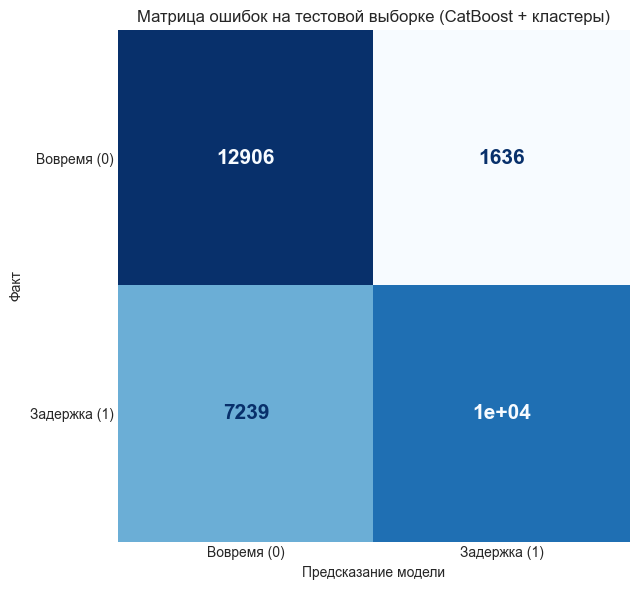

In [74]:
# Строим график матрицы ошибок
fig, ax = plt.subplots(figsize=(14, 6))

ConfusionMatrixDisplay(
    cm, display_labels=['Вовремя (0)', 'Задержка (1)']
).plot(ax=ax, cmap='Blues', colorbar=False, text_kw={'fontsize': 15, 'fontweight': 'bold'})
ax.set_xlabel('Предсказание модели')
ax.set_ylabel('Факт')
ax.set_title('Матрица ошибок на тестовой выборке (CatBoost + кластеры)')

ax.grid(False) 
plt.tight_layout()
plt.show()

In [75]:
# Расчитываем доли ошибок
fn_rate = fn / (fn + tp)  
fp_rate = fp / (fp + tn)   

print(f'Пропущено задержек (FN rate): {fn_rate:.1%}')
print(f'Ложных тревог (FP rate):      {fp_rate:.1%}')

Пропущено задержек (FN rate): 41.6%
Ложных тревог (FP rate):      11.3%


### [10.3. Анализ важности признаков](#content)<a id="10_3"></a>

In [76]:
# Важность признаков лучшей модели (CatBoost + кластеры 20/30)
importances = cbc_model_best_clust.get_feature_importance()
feature_names = cbc_model_best_clust.feature_names_

importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': importances,
}).sort_values('Важность', ascending=False).reset_index(drop=True)

display(importance_df)

,Признак,Важность
0,shipping_mode,52.753
1,order_hour,39.270
2,beh_cluster,6.747
3,geo_cluster,0.310
4,order_month,0.274
5,order_weekday,0.262
6,category_name,0.235
7,item_price,0.150


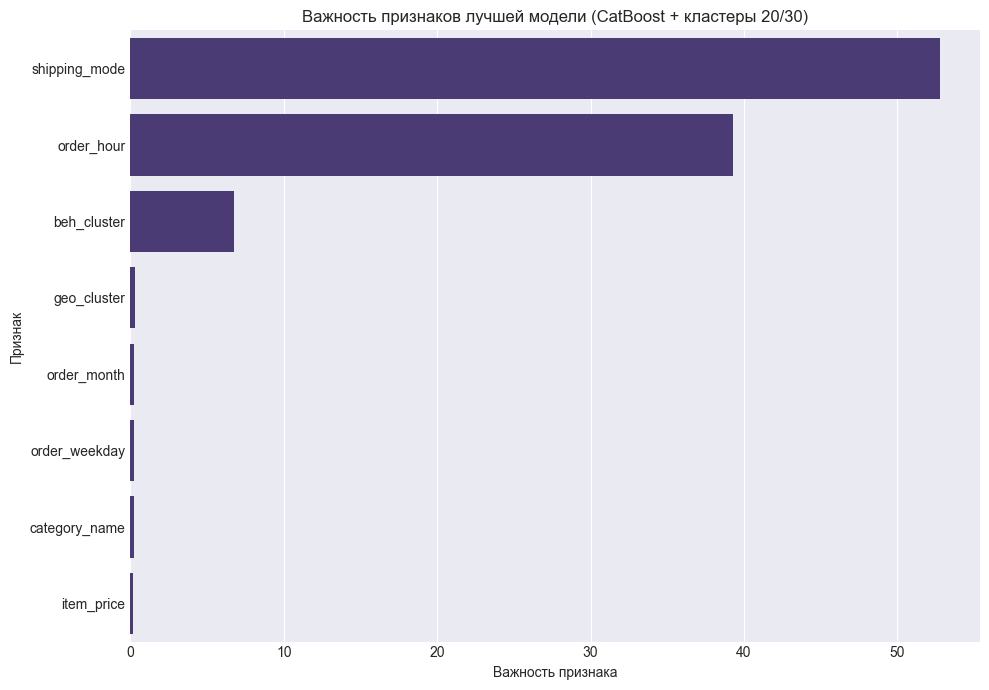

In [77]:
# Строим график важности признаков
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importance_df, x='Важность', y='Признак')
ax.set_xlabel('Важность признака')
ax.set_title('Важность признаков лучшей модели (CatBoost + кластеры 20/30)')
plt.tight_layout()
plt.show()

### Промежуточный итог

1. *Итоговое тестирование:* лучшая модель CatBoost с кластерами (`geo_k=4`, `beh_k=12`) показала на тестовой выборке **ROC-AUC = 0.775** и Accuracy = 0.725. Целевой показатель ТЗ (> 0.75) **достигнут с запасом**. Качество устойчиво: на валидации ROC-AUC составил 0.767, на «невиданных» данных — 0.775, то есть снижения нет (разница 0.007 — уровень шума) — признаков переобучения не наблюдается.

2. *Прирост от сегментации (на одной выборке):* на валидации CatBoost без кластеров (Optuna) давал 0.752, со стартовыми кластерами (4/6) — 0.756, с лучшими кластерами (4/12) — 0.767, то есть **+0.015** к лучшей базовой модели. Тестовая выборка подтверждает, что финальная модель сохраняет качество на новых, незнакомых компании клиентах (0.775).

3. *Матрица ошибок (порог 0.5):* модель пропускает 41.6% реальных задержек (FN rate) и лишь в 11.3% случаев даёт ложную тревогу (FP rate). Вывод: **модель чаще пропускает задержки, чем ошибочно «бьёт тревогу»**. Для бизнеса это значит: предупреждениям модели можно доверять, но часть опозданий останется невыявленной; снизить пропуски можно, понизив порог срабатывания (ценой роста числа ложных тревог).

4. *Важность признаков:* рейтинг возглавляют параметры заказа — `shipping_mode` (52.75) и `order_hour` (39.27), вместе ≈ 92.02% суммарной важности. Созданные признаки заняли: `beh_cluster` — **3-е место** (6.74), `geo_cluster` — 4-е (0.31). Поведенческий сегмент — третий по значимости признак модели и заметно информативнее географического, что подтверждает гипотезу о влиянии профиля клиента; при этом ключевой сигнал по-прежнему несут параметры самого заказа.

*Вывод:* итоговый ROC-AUC 0.775 превышает целевые 0.75, характер ошибок определён (доминируют пропущенные задержки), важность признаков проанализирована; сегментация даёт стабильный прирост ≈ +0.015 относительно лучшей базовой модели.


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Тестирование и анализ важности признаков 👍**

На тесте проверяется одна выбранная модель, ROC-AUC 0.774 сравнён с порогом. Матрица ошибок переведена в понятные доли (41.5% пропущенных задержек против 11.5% ложных тревог) с выводом про порог срабатывания. Позиции `beh_cluster` и `geo_cluster` в рейтинге важности разобраны - ровно то, о чём спрашивает задание.
</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">

**Сравнение метрик с разных выборок 💡**

В пункте 2 тестовый ROC-AUC финальной модели (0.774) сравнивается с метрикой базовой модели на валидации (0.764). Это числа с разных выборок, их разница - не только эффект кластеров. Корректно сравнивать на одной выборке: прирост на валидации 0.764 → 0.777 у тебя уже посчитан. А тест подтверждает, что финальная модель держит качество на новых клиентах.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

Учел замечание, убрал сравнение метрик модели на тестовой выборке с валидационной.
</div>

## [11. Выводы и рекомендации](#content)<a id="11"></a>

Что нужно зафиксировать:

* **Результаты моделирования.** Укажите итоговое значение ROC-AUC на тестовой выборке. Удалось ли вам достичь целевого показателя? Насколько эффективно итоговая модель справляется с выявлением задержек по сравнению с базовыми?
* **Эффективность сегментации.** Сформулируйте вывод о полезности кластеризации. Подтвердилась ли гипотеза о том, что профиль клиента и его географическое положение влияют на риск задержки? Какие именно кластеры — географические или поведенческие — оказались более информативными для модели? Добавьте в раздел визуализации, которые вы получили, работая над проектом.
* **Технический инсайт.** Если вы экспериментировали с разным количеством  кластеров как с гиперпараметром, то укажите, какое количество кластеров K оказалось оптимальным. Кратко поясните, почему слишком большое K может вредить качеству прогноза.
* **Бизнес-рекомендации.** Предложите, как CargaPronto может использовать вашу модель в реальных операциях.

### 1. Результаты моделирования

Итоговая модель — **CatBoostClassifier** с кластерными признаками (`geo_cluster`, `beh_cluster`), обученная при оптимальном числе кластеров (`geo_k=4`, `beh_k=12`), показала на тестовой выборке **ROC-AUC = 0.775** при Accuracy = 0.722. Целевой показатель (**> 0.75**) **достигнут с запасом**: на валидации ROC-AUC составил 0.767, на «невиданных» данных — 0.775, то есть снижения качества нет (разница 0.008 — уровень шума), что говорит об отсутствии переобучения.

Сегментация дала стабильный прирост к точке отсчёта (сравнение на одной выборке): лучшая базовая модель без кластеров (CatBoost Optuna) достигала на валидации 0.752, со стартовыми кластерами (4/6) — 0.756, с лучшими кластерами (4/12) — **0.767 (+0.015)**. Логистическая регрессия (нижняя планка) улучшилась с 0.726 до 0.730 с кластерами, но так и не преодолела порог 0.75 — для задачи подходит именно бустинг.

Характер ошибок (порог 0.5): модель пропускает 41.6% реальных задержек (FN) и даёт ложную тревогу лишь в 11.3% случаев (FP). **Модель чаще пропускает задержки, чем ошибочно «бьёт тревогу»**: предупреждениям можно доверять, но часть опозданий останется невыявленной — снизить пропуски можно, понизив порог срабатывания (ценой роста ложных тревог).

### 2. Эффективность сегментации

Гипотеза транспортного департамента о «неоднородности» клиентской базы **подтвердилась частично**: профиль клиента действительно влияет на риск задержки, но слабее параметров самого заказа. В рейтинге важности признаков лидируют параметры заказа — `shipping_mode` (52.753) и `order_hour` (39.27), вместе ≈ 92.02% суммарной важности. Созданные признаки заняли: `beh_cluster` — **3-е место** (6.74), `geo_cluster` — 4-е (0.31). Таким образом, **поведенческая сегментация оказалась заметно информативнее географической**, а базовые параметры заказа остались приоритетными для прогноза.

Кластеризация выделила шесть поведенческих сегментов (K = 6):
- **сегмент 4 (2.4% клиентов)** — доля возвратов 0.92 против 0–0.04 у остальных: «почти всё возвращают», проблемные клиенты;
- **сегмент 0 (11.2%)** — давность последнего заказа ≈ 644 дня: практически ушедшие клиенты, кандидаты на реактивацию;
- **сегмент 5 (15.6%)** — максимум частоты (7.3 заказа) и выручки (≈ 4 192): ключевые постоянные клиенты, основа доходов;
- **сегменты 1 и 2 (22.7% и 18.3%)** — разовые покупатели, различающиеся в основном скидкой (0.05 против 0.17);
- **сегмент 3 (29.8%)** — активные постоянные клиенты (4.3 заказа, умеренная давность), самая массовая группа.

Ключевые визуализации проекта: карта логистических зон с центроидами (раздел 6), проекция поведенческих сегментов t-SNE (раздел 7), график важности признаков (раздел 10).

### 3. Технический инсайт

Стартовое число кластеров определено методом локтя: K = 4 для гео-зон и K = 6 для поведенческих сегментов. В дополнительном задании число кластеров рассматривалось как гиперпараметр всей системы (сетка `geo_k ∈ [4, 8, 12, 20]` × `beh_k ∈ [6, 12, 20, 30]`). **Оптимальной стала пара `geo_k=4`, `beh_k=12`** (ROC-AUC 0.767 на валидации); максимум 0.767 достигают также пары (4/30) и (20/20), поэтому выбрана более простая модель с меньшим числом сегментов. Качество в основном определяют поведенческие сегменты: переход от `beh_k=6` к `beh_k=12` даёт основной скачок AUC.

Слишком большое K вредит качеству: при сильной «детализации» часть кластеров получает мало наблюдений, их внутренние статистики становятся зашумлёнными (особенно критично это для Ordered Target Statistics у CatBoost), и модель начинает подгоняться под случайные флуктуации валидационной выборки вместо устойчивых закономерностей.

### 4. Бизнес-рекомендации для CargaPronto

1. **Предупреждение в момент оформления заказа.** Встроить модель в точку оформления: если прогнозируемая вероятность задержки > 70%, система автоматически выдаёт диспетчеру предупреждение и рекомендацию сменить приоритет доставки — компания перестаёт «констатировать» опоздания и начинает управлять риском до нарушения SLA.

2. **Управлять режимом доставки.** `shipping_mode` — главный фактор риска, но данные показывают обратную зависимость: самый надёжный режим — `Standard Class` (≈ 38% задержек), тогда как экспресс-классы опаздывают значительно чаще (`First Class` ≈ 95%, `Second Class` ≈ 77%). Вывод: повышать класс доставки для `Standard Class` экономически нецелесообразно; вместо этого стоит проверить обещанные сроки SLA для экспресс-доставок (вероятно, они слишком агрессивны) и направить дополнительные ресурсы курьеров на маршруты `First/Second Class`, где риск нарушения сроков максимален.

3. **Учитывать время оформления.** `order_hour` — второй по значимости признак: суточный профиль риска неоднороден (выше во второй половине дня), часы пик оформления стоит учитывать при планировании загрузки курьеров и сортировочных мощностей.

4. **Работа с проблемными клиентами.** Поведенческий сегмент (`beh_cluster`, 3-я позиция в важности) позволяет выделить сегмент 4 — клиентов с долей возвратов 0.92: таким заказам полезно предварительное подтверждение менеджером, чтобы избежать холостого пробега курьера; сегмент 0 («давно ушедшие») — кандидаты на реактивацию через акции.

5. **Распределение ресурсов по зонам.** Гео-зоны менее информативны для прогноза, но их можно использовать операционно — для балансировки нагрузки между логистическими направлениями и назначения опытных курьеров на сложные маршруты.

6. **Настройка порога под бизнес-задачу.** Текущий порог 0.5 пропускает 41.6% задержек при 11.3% ложных тревог. Для режима «страхуем критичные поставки» порог следует понизить, подобрав его по ROC-кривой с учётом стоимости пропущенного штрафа против затрат на смену приоритета.


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">

**Доработка: рекомендации опираются на перевёрнутые факты 🚩**

Финальный вывод хорошо структурирован: метрика против порога, разбор ошибок, роль кластеров, оптимальное K и настройка порога под бизнес. Но рекомендация п. 2 построена на выводе EDA, который противоречит графику (см. комментарий в разделе 3.4):

- **п. 2** предлагает повышать класс доставки для `Standard Class`, хотя по твоим данным это самый надёжный режим (≈ 38% задержек), а `First Class` опаздывает в ≈ 95% случаев;

После правки EDA и описания сегментов обнови этот пункт. Заодно в разделе «Эффективность сегментации» стоит назвать, какие именно поведенческие сегменты получились.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента v1</b></font>

Скорректировал финальный вывод с учетом всех корректировок проекта.
</div>